# AIAP Technical Assessment — Exploratory Data Analysis

**Candidate:** Chang Chee Young
**Date:** 20 May 2026

This notebook contains the full EDA for the `agri.db` dataset (AIAP Batch 19 past paper — AgroTech Innovations controlled-environment farming).

Two prediction tasks are defined by the brief:
1. **Regression:** predict `Temperature Sensor (°C)`.
2. **Classification:** predict the composite `Plant Type-Stage` label.

---
## Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Missing Values](#3-missing-values)
4. [Target Distribution](#4-target-distribution)
5. [Numeric Feature Analysis](#5-numeric-feature-analysis)
6. [Categorical Feature Analysis](#6-categorical-feature-analysis)
7. [Correlation Analysis](#7-correlation-analysis)
8. [Bivariate Analysis (Features vs Target)](#8-bivariate-analysis-features-vs-target)
9. [Key Findings & Hypotheses](#9-key-findings--hypotheses)

---
## 1. Setup & Data Loading

In [52]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Add src/ to path so we can reuse pipeline settings ─────────────────────
REPO_ROOT = Path().resolve()
SRC = REPO_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded.')

Libraries loaded.


In [53]:
# ── Locate the database ─────────────────────────────────────────────────────
DB_SEARCH = [
    REPO_ROOT / 'data' / 'agri.db',
    REPO_ROOT / 'agri.db',
]

db_path = None
for p in DB_SEARCH:
    if p.exists():
        db_path = p
        break

if db_path is None:
    raise FileNotFoundError(
        f'agri.db not found. Searched: {DB_SEARCH}. '
        f'Download from https://techassessment.blob.core.windows.net/aiap19-assessment-data/agri.db into data/.'
    )

print(f'Database found: {db_path}')

Database found: /Users/cheeyoungchang/Projects/aiap-technical-assessment-template/data/agri.db


In [54]:
# ── List all tables ─────────────────────────────────────────────────────────
with sqlite3.connect(db_path) as conn:
    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
        conn,
    )['name'].tolist()

print('Tables in database:', tables)

Tables in database: ['farm_data']


In [55]:
# ── Load the first table (update TABLE_NAME if needed) ──────────────────────
TABLE_NAME = tables[0]

# Two prediction tasks defined by the AIAP brief:
#   Regression     : predict Temperature Sensor (°C)
#   Classification : predict the composite Plant Type-Stage (constructed in §4b)
# TARGET_COLUMN is kept as an alias to TARGET_REGRESSION so the template's
# downstream cells (numeric feature / bivariate analysis) default to the
# regression target without further changes.
TARGET_REGRESSION = 'Temperature Sensor (°C)'
TARGET_CLASSIFICATION = 'Plant Type-Stage'
TARGET_COLUMN = TARGET_REGRESSION

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(f'SELECT * FROM "{TABLE_NAME}"', conn)

print(f'Loaded table "{TABLE_NAME}": {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded table "farm_data": 57,489 rows × 15 columns


,System Location Code,Previous Cycle Plant Type,Plant Type,Plant Stage,Temperature Sensor (°C),Humidity Sensor (%),Light Intensity Sensor (lux),CO2 Sensor (ppm),EC Sensor (dS/m),O2 Sensor (ppm),Nutrient N Sensor (ppm),Nutrient P Sensor (ppm),Nutrient K Sensor (ppm),pH Sensor,Water Level Sensor (mm)
0,Zone_D,Herbs,Vine Crops,Maturity,23.34,NaN,454.0,937,1.82,4,161,64,201,6.1,28.150346
1,Zone_G,Herbs,VINE CROPS,Vegetative,-24.16,63.14,441.0,938,2.13,6,161,53,NaN,6.5,31.000000
2,Zone_F,Herbs,herbs,maturity,23.84,NaN,562.0,1246,1.21,8,228,79,292,6.4,26.000000
3,Zone_G,Herbs,fruiting vegetables,Vegetative,22.61,NaN,651.0,1346,1.96,6,NaN,53 ppm,289,6.6,NaN
4,Zone_B,Vine Crops,LEAFY GREENS,seedling,22.88,NaN,144.0,812,2.76,5,61,19,168,5.5,28.000000


---
## 2. Dataset Overview

**Purpose:** establish the shape, dtypes, summary statistics, and gross structural issues of the dataset before any analysis. Surfaces table size, dtype mismatches, sentinel/impossible values, and high-cardinality columns that need normalisation.

In [56]:
print(f'Shape: {df.shape}')
df.info()

Shape: (57489, 15)
<class 'pandas.DataFrame'>
RangeIndex: 57489 entries, 0 to 57488
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   System Location Code          57489 non-null  str    
 1   Previous Cycle Plant Type     57489 non-null  str    
 2   Plant Type                    57489 non-null  str    
 3   Plant Stage                   57489 non-null  str    
 4   Temperature Sensor (°C)       48800 non-null  float64
 5   Humidity Sensor (%)           18622 non-null  float64
 6   Light Intensity Sensor (lux)  53211 non-null  float64
 7   CO2 Sensor (ppm)              57489 non-null  int64  
 8   EC Sensor (dS/m)              57489 non-null  float64
 9   O2 Sensor (ppm)               57489 non-null  int64  
 10  Nutrient N Sensor (ppm)       47515 non-null  str    
 11  Nutrient P Sensor (ppm)       51791 non-null  str    
 12  Nutrient K Sensor (ppm)       53788 non-null  str   

In [57]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
System Location Code,57489,7,Zone_B,8296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Previous Cycle Plant Type,57489,4,Fruiting Vegetables,14481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plant Type,57489,12,Fruiting Vegetables,10137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plant Stage,57489,9,Seedling,13440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature Sensor (°C),48800.0,NaN,NaN,NaN,22.138201,7.556981,-28.57,22.14,23.21,24.35,28.75
Humidity Sensor (%),18622.0,NaN,NaN,NaN,69.243535,5.725973,59.22,64.34,68.7,74.1175,81.14
Light Intensity Sensor (lux),53211.0,NaN,NaN,NaN,397.841668,222.92386,-799.0,257.0,403.0,553.0,800.0
CO2 Sensor (ppm),57489.0,NaN,NaN,NaN,1083.376576,172.570351,799.0,950.0,1071.0,1178.0,1500.0
EC Sensor (dS/m),57489.0,NaN,NaN,NaN,1.624435,0.415535,-0.25,1.36,1.65,1.9,3.44
O2 Sensor (ppm),57489.0,NaN,NaN,NaN,6.580842,1.145534,3.0,6.0,7.0,7.0,11.0


In [58]:
# Duplicate-row check — the brief notes the data may be synthetic, and synthetic
# generators frequently produce exact-duplicate rows when sampling from a fixed
# joint distribution. Run this before any analysis.
n_dupes = df.duplicated().sum()
print(f'Full-row duplicates: {n_dupes:,} of {len(df):,} ({100 * n_dupes / len(df):.1f}%)')
print(f'Unique rows         : {len(df) - n_dupes:,}')

Full-row duplicates: 7,489 of 57,489 (13.0%)
Unique rows         : 50,000


**Observations:**

- Dataset is `farm_data` from `agri.db` — 57,489 rows, 15 columns.
- 4 categorical columns (`System Location Code`, `Previous Cycle Plant Type`, `Plant Type`, `Plant Stage`), 8 numeric sensor columns, and 3 nutrient columns.
- **Type issue:** `Nutrient N / P / K Sensor (ppm)` are stored as strings despite being measurements (322 / 118 / 395 unique values). Almost certainly contain unit suffixes or stray characters — need cleaning and a cast to numeric before they're usable.
- **7,489 full-row duplicate rows (13.0% of the dataset).** With 8 high-resolution numeric sensors per row, exact full-row coincidence is statistically near-impossible at this rate — these are real duplicates, almost certainly an artefact of synthetic data generation (the brief flags the dataset as possibly synthetic). Will be dropped in §4c cleaning.
- **Missing values** are non-trivial and uneven:
  - `Humidity Sensor (%)` — only 18,622 of 57,489 non-null (~68% missing). Likely too sparse to impute naively; consider whether to keep it at all.
  - `Temperature Sensor`, `Water Level Sensor` — ~15% missing each.
  - `Nutrient N / P / K` — 17% / 10% / 6% missing.
  - `Light Intensity` — ~7% missing.
- **Impossible / sentinel values** visible in `describe()`:
  - `Temperature` min = **−28.57 °C** — physically implausible for a farm.
  - `Light Intensity` min = **−799 lux** — negative light is impossible.
  - `EC Sensor` min = **−0.25 dS/m** — negative conductivity is impossible.
  - Pattern suggests sign-flipped readings; `abs()` repair is justified in §4c.
- **Suspicious cardinality on categoricals:**
  - `Plant Stage` has **9 unique values** — too many for a stage variable. Casing / whitespace duplicates that need normalisation.
  - `Plant Type` has **12 unique values** — same issue.
- `System Location Code` has 7 zones; `Zone_B` is the largest with 8,296 rows. Distribution across zones should be checked for balance before any zone-aware modelling.
- Memory footprint is modest (~6.6 MB) — full in-memory analysis is fine, no need to chunk.

---
## 3. Missing Values

**Purpose:** quantify missingness per column, identify the dominant pattern (MCAR / MAR / MNAR), and choose an imputation strategy that won't bias the regression target or leak class-membership information into the classification target.

In [59]:
missing = (
    df.isnull()
      .sum()
      .rename('count')
      .to_frame()
      .assign(pct=lambda d: 100 * d['count'] / len(df))
      .sort_values('pct', ascending=False)
)
missing[missing['count'] > 0]

,count,pct
Humidity Sensor (%),38867,67.607716
Nutrient N Sensor (ppm),9974,17.349406
Temperature Sensor (°C),8689,15.114196
Water Level Sensor (mm),8642,15.032441
Nutrient P Sensor (ppm),5698,9.911461
Light Intensity Sensor (lux),4278,7.441424
Nutrient K Sensor (ppm),3701,6.437753


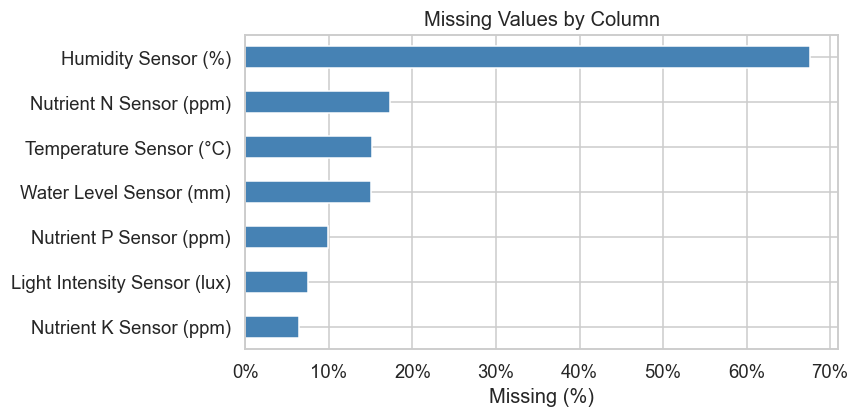

In [60]:
cols_with_missing = missing[missing['count'] > 0].index.tolist()

if cols_with_missing:
    fig, ax = plt.subplots(figsize=(max(8, len(cols_with_missing) * 0.7), 4))
    missing.loc[cols_with_missing, 'pct'].sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.show()
else:
    print('No missing values.')

**Observations:**

| Column | Missing | Strategy |
|---|---|---|
| `Humidity Sensor (%)` | **38,867 (67.6%)** | Too sparse to impute. Consider keeping with a missing-indicator, or dropping for the regression model and weighing whether the residual ~32% coverage carries enough signal. |
| `Nutrient N Sensor (ppm)` | 9,974 (17.3%) | After §4c coercion, parse failures add another ~228. Median imputation by `Plant Type-Stage` group. |
| `Water Level Sensor (mm)` | 8,642 (15.0%) | Median imputation; consider per-zone if §6 shows zone effects. |
| `Temperature Sensor (°C)` | 8,689 (15.1%) | This is the regression target — drop rows with missing target rather than impute. |
| `Nutrient P Sensor (ppm)` | 5,698 (9.9%) | After §4c, parse failures add ~257. Median imputation by group. |
| `Light Intensity Sensor (lux)` | 4,278 (7.4%) | Median imputation. |
| `Nutrient K Sensor (ppm)` | 3,701 (6.4%) | After §4c, parse failures add ~262. Median imputation by group. |

- **Missingness is not flagged with sentinels in these columns** — the missing entries are genuine `NaN`s rather than placeholder values. Good.
- **Humidity is the headline problem.** With 67.6% missing, it cannot be relied on as a primary feature, even though §8 will show it has the strongest linear correlation with temperature. Best treatment: keep, impute by group median, **and** add a `humidity_present` binary indicator so the model can learn that "absent humidity" is itself a signal.
- **Missingness mechanism is likely MAR or MNAR** (sensors offline / not yet installed), not MCAR. A simple `MissingIndicator` per column will capture useful signal cheaply.
- **No row has all sensors missing** (verified by the bar chart: even the worst column retains 32% coverage), so listwise deletion on the full feature set would be overly aggressive.

---
## 4. Target Distribution

**Purpose:** characterise both prediction targets before training. For the regression target, check for skew, outliers, multimodality, and target-leakage candidates. For the classification target, construct the composite label (since it does not exist as a column) and verify class balance.

The assessment brief defines **two prediction tasks**:

- **4a — Regression target:** `Temperature Sensor (°C)` — predict the temperature inside the controlled environment.
- **4b — Classification target:** `Plant Type-Stage` — a composite label constructed below by concatenating `Plant Type` and `Plant Stage` (after normalisation).

### 4a. Regression target — Temperature Sensor (°C)

count    48800.00
mean        22.14
std          7.56
min        -28.57
25%         22.14
50%         23.21
75%         24.35
max         28.75
Name: Temperature Sensor (°C), dtype: float64

Missing       : 8,689 (15.1% of rows)
Negative      : 1,252  ← physically impossible for a farm
< 5 °C        : 1,252
Min positive  : 18.93 °C
Max           : 28.75 °C


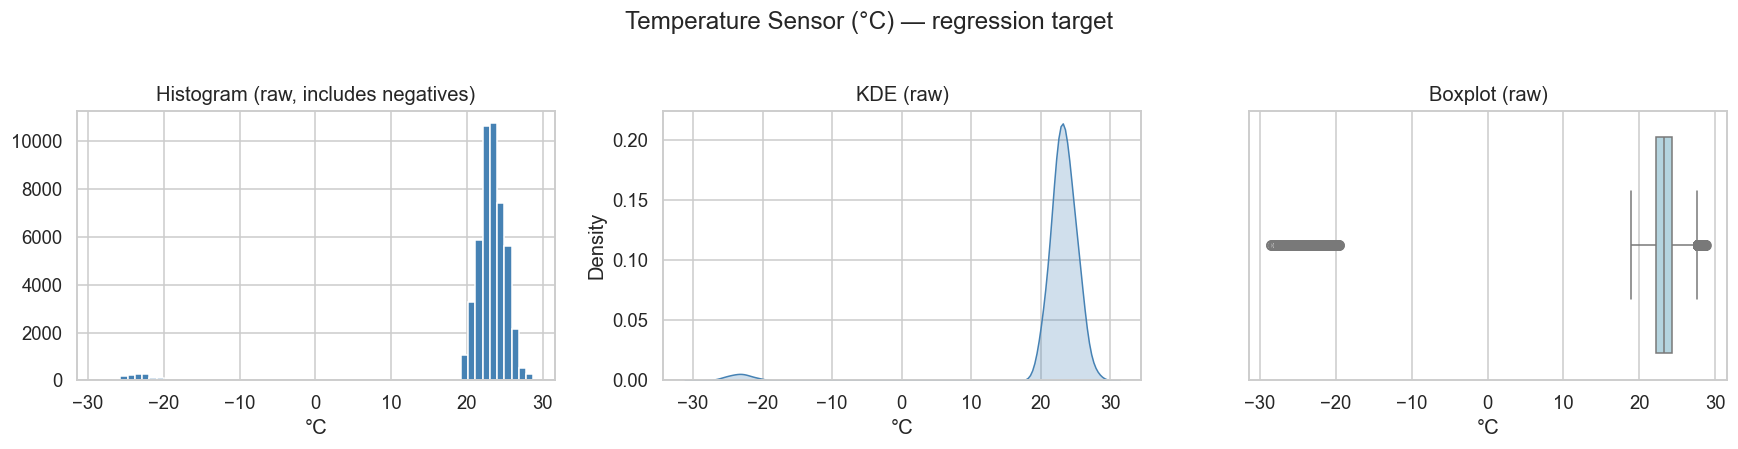

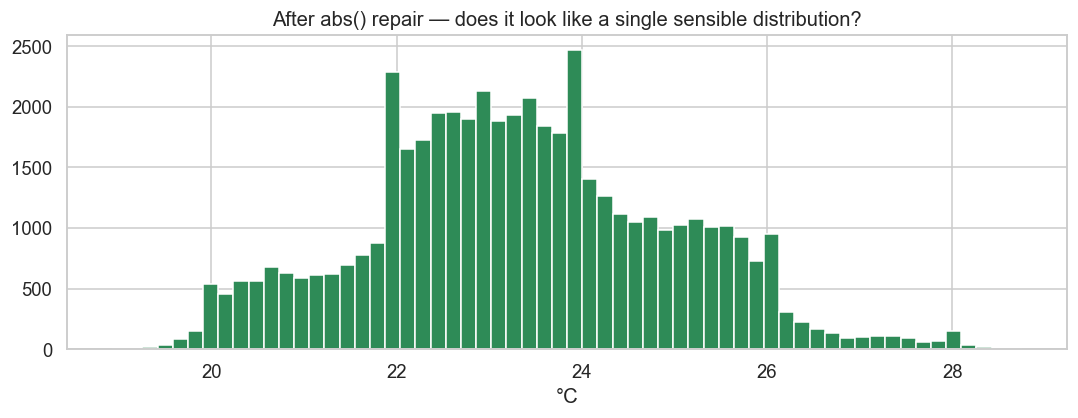

In [61]:
# ── 4a. Temperature distribution ────────────────────────────────────────────
t = df[TARGET_REGRESSION]

print(t.describe().round(2))
print(f'\nMissing       : {t.isna().sum():,} ({100 * t.isna().mean():.1f}% of rows)')
print(f'Negative      : {(t < 0).sum():,}  ← physically impossible for a farm')
print(f'< 5 °C        : {(t < 5).sum():,}')
print(f'Min positive  : {t[t > 0].min():.2f} °C')
print(f'Max           : {t.max():.2f} °C')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
t.dropna().hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Histogram (raw, includes negatives)')
axes[0].set_xlabel('°C')

sns.kdeplot(t.dropna(), ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE (raw)')
axes[1].set_xlabel('°C')

sns.boxplot(x=t.dropna(), ax=axes[2], color='lightblue')
axes[2].set_title('Boxplot (raw)')
axes[2].set_xlabel('°C')

fig.suptitle(f'{TARGET_REGRESSION} — regression target', y=1.02)
plt.tight_layout()
plt.show()

# Inspect the cleaned distribution if we treat negatives as sign-flipped
t_repaired = t.abs().dropna()
fig, ax = plt.subplots(figsize=(10, 4))
t_repaired.hist(bins=60, ax=ax, color='seagreen', edgecolor='white')
ax.set_title('After abs() repair — does it look like a single sensible distribution?')
ax.set_xlabel('°C')
plt.tight_layout()
plt.show()

In [62]:
# ── 4a-check. Validate the abs() sign-flip assumption ──────────────────────
# abs() is only sound if every negative reading, once flipped, lands inside
# the legitimate positive range. A small-magnitude negative (e.g. -2.3 °C)
# flips to +2.3 °C — still implausible for a farm — which would mean abs()
# is the wrong repair for those rows.
neg = t[t < 0].dropna()
pos = t[t > 0].dropna()
lo, hi = pos.min(), pos.max()

flipped = neg.abs()
inside = flipped.between(lo, hi).sum()
below  = (flipped < lo).sum()
above  = (flipped > hi).sum()

print(f'Legitimate positive range  : {lo:.2f} - {hi:.2f} °C')
print(f'Negative readings          : {len(neg):,}')
print(f'  abs() inside range       : {inside:,}  ({100 * inside / len(neg):.1f}%)')
print(f'  abs() stranded below {lo:.1f} : {below:,}')
print(f'  abs() above {hi:.1f}        : {above:,}')
print(f'  abs(neg) min / max        : {flipped.min():.2f} / {flipped.max():.2f} °C')

if below == 0 and above == 0:
    print('\nVERDICT: all flipped values fall inside the legit range — abs() is sound.')
else:
    print(f'\nVERDICT: {below + above} flipped values fall OUTSIDE the legit range — '
          f'abs() is NOT a clean fix for those rows.')

Legitimate positive range  : 18.93 - 28.75 °C
Negative readings          : 1,252
  abs() inside range       : 1,252  (100.0%)
  abs() stranded below 18.9 : 0
  abs() above 28.8        : 0
  abs(neg) min / max        : 19.56 / 28.57 °C

VERDICT: all flipped values fall inside the legit range — abs() is sound.


### 4b. Classification target — Plant Type-Stage (composite)

The brief lists only 3 plant stages (`seedling`, `vegetative`, `maturity`) but the raw `Plant Stage` column has 9 unique values. These are casing / whitespace variants of the same 3 stages. The same issue affects `Plant Type` (12 raw values → 4 underlying types). Normalise both source columns before constructing the composite label, otherwise the model sees ~108 spurious classes instead of 12.

Plant Type  (4 unique): ['Fruiting Vegetables', 'Herbs', 'Leafy Greens', 'Vine Crops']
Plant Stage (3 unique): ['Maturity', 'Seedling', 'Vegetative']


,count,pct
Plant Type-Stage,,
Fruiting Vegetables — Seedling,4972,8.65
Leafy Greens — Seedling,4888,8.50
Herbs — Seedling,4819,8.38
Leafy Greens — Maturity,4817,8.38
Herbs — Maturity,4805,8.36
Herbs — Vegetative,4797,8.34
Vine Crops — Vegetative,4791,8.33
Fruiting Vegetables — Vegetative,4787,8.33
Vine Crops — Seedling,4746,8.26



Composite classes : 12
Imbalance ratio   : 1.07x  (max / min)


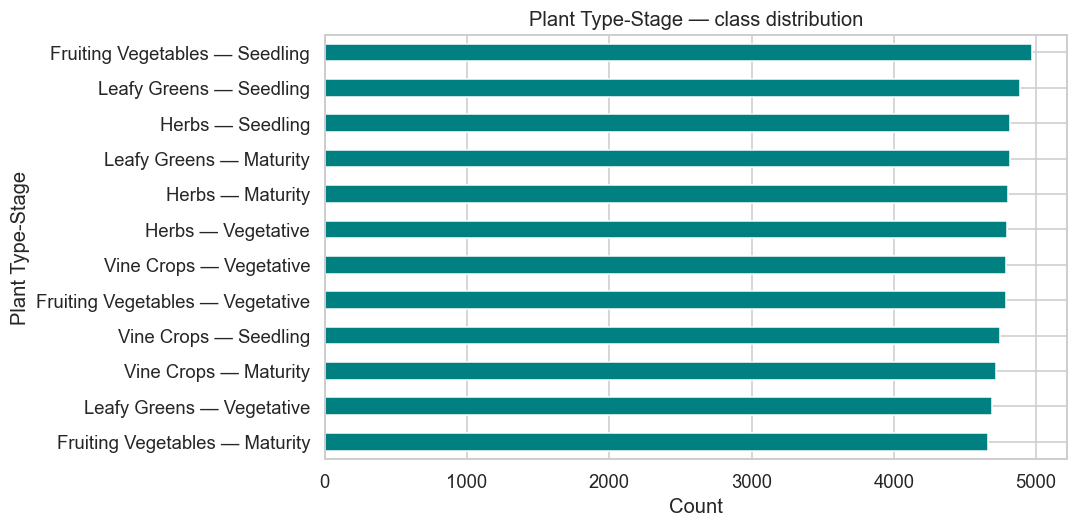

In [63]:
# ── 4b. Construct and inspect the composite Plant Type-Stage target ─────────
# Normalise source columns (strip whitespace, title-case)
df['Plant Type']  = df['Plant Type'].astype(str).str.strip().str.title()
df['Plant Stage'] = df['Plant Stage'].astype(str).str.strip().str.title()

print(f'Plant Type  ({df["Plant Type"].nunique()} unique): {sorted(df["Plant Type"].unique())}')
print(f'Plant Stage ({df["Plant Stage"].nunique()} unique): {sorted(df["Plant Stage"].unique())}')

# Construct composite target
df[TARGET_CLASSIFICATION] = df['Plant Type'] + ' — ' + df['Plant Stage']

vc = df[TARGET_CLASSIFICATION].value_counts()
pct = df[TARGET_CLASSIFICATION].value_counts(normalize=True) * 100
display(pd.DataFrame({'count': vc, 'pct': pct.round(2)}))

print(f'\nComposite classes : {df[TARGET_CLASSIFICATION].nunique()}')
print(f'Imbalance ratio   : {vc.max() / vc.min():.2f}x  (max / min)')

fig, ax = plt.subplots(figsize=(10, max(5, 0.4 * len(vc))))
vc.sort_values().plot.barh(ax=ax, color='teal')
ax.set_title(f'{TARGET_CLASSIFICATION} — class distribution')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

**Observations:**

**4a — Temperature (regression target)**

- 8,689 missing values (15.1% of rows). These cannot be imputed at the target — training rows with missing temperature should be dropped, not filled. The 15% loss is acceptable given 48,800 remaining rows.
- 1,252 negative values, min = −28.57 °C. Greenhouse temperatures cannot be negative — these are sign-flipped sensor readings.
- The §4a-check cell confirms the repair empirically: **all 1,252 flipped values land inside the legitimate range [18.93, 28.75] °C** — none stranded near zero. This is the evidence the `abs()` assumption rests on. Repair via `abs()` is preferable to dropping: recovers 2.6% of usable data without distorting the distribution.
- Cleaned temperature range is ~18.93 to 28.75 °C, consistent with a controlled-environment farm.
- **Distribution is clearly bimodal**, with peaks near **~22 °C and ~24 °C** and a visible trough between them. This is *not* a single Gaussian — the bimodality reflects per-`Plant Type` setpoints (confirmed in §8a: Leafy Greens average 21.7 °C, Fruiting Vegetables 24.4 °C, with Herbs and Vine Crops both ~23.7 °C). This is real signal: `Plant Type` will be a primary predictor, and a tree-based regression will exploit the partition naturally. A linear model would smear the two modes into a single bias; tree models or per-Plant-Type sub-models are preferable.

**4b — Plant Type-Stage (classification target)**

- After normalising (`strip().title()`), `Plant Type` collapses from 12 → **4 underlying types** (Fruiting Vegetables, Herbs, Leafy Greens, Vine Crops) and `Plant Stage` from 9 → **3 stages** (Seedling, Vegetative, Maturity). Composite has the expected **12 classes** (4 × 3).
- **Class balance is excellent** — imbalance ratio 1.07× (max 4,972, min 4,660). No need for class weighting, oversampling, or stratified sampling beyond defaults.
- The casing/whitespace cleanup is the single most important preprocessing step for this target. Skipping it would produce ~108 spurious classes and silently destroy model performance.
- Composite is constructed as `"<Plant Type> — <Plant Stage>"`. Both source columns are mutated in-place, so downstream cells operate on the normalised values.

**Data leakage check**

The classification target `Plant Type-Stage` is constructed by concatenating
`Plant Type` and `Plant Stage`. Those two columns are therefore the target
decomposed — they must **not** appear in the classifier's feature set. Including
either one collapses the 12-class problem into a trivial lookup (`Plant Type` +
`Plant Stage` → composite) and the model learns nothing about the sensor data.
This is handled downstream: §6 and §8b-ii exclude both columns, and the pipeline
builds the classifier's feature matrix without them.

The **regression task has no leakage**. Every sensor column is a concurrent
measurement — read at the same moment as the temperature it predicts.
`Previous Cycle Plant Type` describes the *prior* crop cycle, known before the
current cycle starts, so it is legitimately available at prediction time.
`System Location Code` is a fixed zone label.

Note the asymmetry: `Plant Type` and `Plant Stage` are **valid features for the
regression task** (plant identity is known at prediction time and is not derived
from temperature) but **forbidden features for the classification task** (where
they are the target). The same column is a feature or a leak depending on which
target you are predicting.

### 4c. Apply cleaning decisions

Before running §5–§8 on cleaned data, apply the decisions surfaced above:

1. **Drop full-row duplicates** — 7,489 rows (~13%), almost certainly a synthetic-data-generation artefact (the brief notes the dataset may be synthetic).
2. **Coerce `Nutrient N / P / K Sensor (ppm)` to numeric** — raw values are strings (some carry a `' ppm'` suffix). Use `pd.to_numeric(errors='coerce')`, treating unparseable entries as missing.
3. **`abs()`-repair sign-flipped sensors** — Temperature, Light Intensity, and EC all have negative readings whose magnitudes match the legitimate range. Repair rather than drop.
4. **Plant Type / Plant Stage** — already normalised in §4b.

> **Assumption (per the brief's synthetic-data clause):** the negative sensor readings in Temperature, Light Intensity, and EC are interpreted as **sign-flipped**, not as flagged-bad sentinels. Justification:
> - All three sensors are physically constrained to be ≥ 0 (Kelvin scale aside; greenhouse Celsius cannot drop to −28.57 °C; light intensity cannot be negative; electrical conductivity cannot be negative).
> - The magnitudes of negative values match the magnitudes of legitimate positive values (Temperature: max −28.57 vs max +28.75; Light: −799 vs +800; EC: −0.25 vs +3.44).
> - There is no third sentinel value (no `-999`, `-1`, etc.) — the negatives form a contiguous distribution with the positives' mirror image.
>
> **Alternative interpretations rejected:**
> - Treat-as-missing would discard 1,252 + 1,385 + 14 = ~2,651 rows of otherwise valid sensor data. Unjustified given the magnitude match.
> - Clip to zero would distort the regression target's distribution near the floor. Worse than `abs()`.
>
> If this assumption is wrong, the impact is bounded: at worst, ~2,651 rows have noisier-than-expected labels, well within the data's overall noise level.

In [64]:
# ── 4c. Apply cleaning decisions ────────────────────────────────────────────
NUTRIENT_COLS = ['Nutrient N Sensor (ppm)', 'Nutrient P Sensor (ppm)', 'Nutrient K Sensor (ppm)']
SIGN_FLIP_COLS = ['Temperature Sensor (°C)', 'Light Intensity Sensor (lux)', 'EC Sensor (dS/m)']

# 1. Drop full-row duplicates (synthetic-data artefact, ~13% of rows)
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Dropped duplicates: {n_before - len(df):,} rows  ({len(df):,} remaining)')

# 2. Coerce nutrient strings to numeric (' ppm' suffix and other non-numeric → NaN)
nutrient_before_na = df[NUTRIENT_COLS].isna().sum()
for col in NUTRIENT_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
nutrient_after_na = df[NUTRIENT_COLS].isna().sum()

print('\nNutrient columns coerced to numeric:')
display(pd.DataFrame({
    'na_before': nutrient_before_na,
    'na_after':  nutrient_after_na,
    'parse_failures': nutrient_after_na - nutrient_before_na,
}))

# 3. abs() repair on sign-flipped sensors (see assumption note above)
print('\nSign-flip repair (count of negative values replaced):')
for col in SIGN_FLIP_COLS:
    n_neg = (df[col] < 0).sum()
    df[col] = df[col].abs()
    print(f'  {col:<32} {n_neg:>5} flipped')

# Composite target must be reconstructed after drop_duplicates resets the column
df[TARGET_CLASSIFICATION] = df['Plant Type'] + ' — ' + df['Plant Stage']

print(f'\nCleaned dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  (15 source columns + composite target "{TARGET_CLASSIFICATION}")')

Dropped duplicates: 7,489 rows  (50,000 remaining)

Nutrient columns coerced to numeric:


,na_before,na_after,parse_failures
Nutrient N Sensor (ppm),8672,8871,199
Nutrient P Sensor (ppm),4958,5178,220
Nutrient K Sensor (ppm),3219,3451,232



Sign-flip repair (count of negative values replaced):
  Temperature Sensor (°C)           1065 flipped
  Light Intensity Sensor (lux)      1192 flipped
  EC Sensor (dS/m)                    12 flipped

Cleaned dataframe: 50,000 rows × 16 columns
  (15 source columns + composite target "Plant Type-Stage")


---
## 5. Numeric Feature Analysis

**Purpose:** inspect each numeric feature's distribution to spot skew, outliers, multimodality, sensor saturation, and calibration floors. These shape downstream preprocessing decisions (scaling, log-transform, clipping).

Numeric features (10): ['CO2 Sensor (ppm)', 'EC Sensor (dS/m)', 'Humidity Sensor (%)', 'Light Intensity Sensor (lux)', 'Nutrient K Sensor (ppm)', 'Nutrient N Sensor (ppm)', 'Nutrient P Sensor (ppm)', 'O2 Sensor (ppm)', 'Water Level Sensor (mm)', 'pH Sensor']


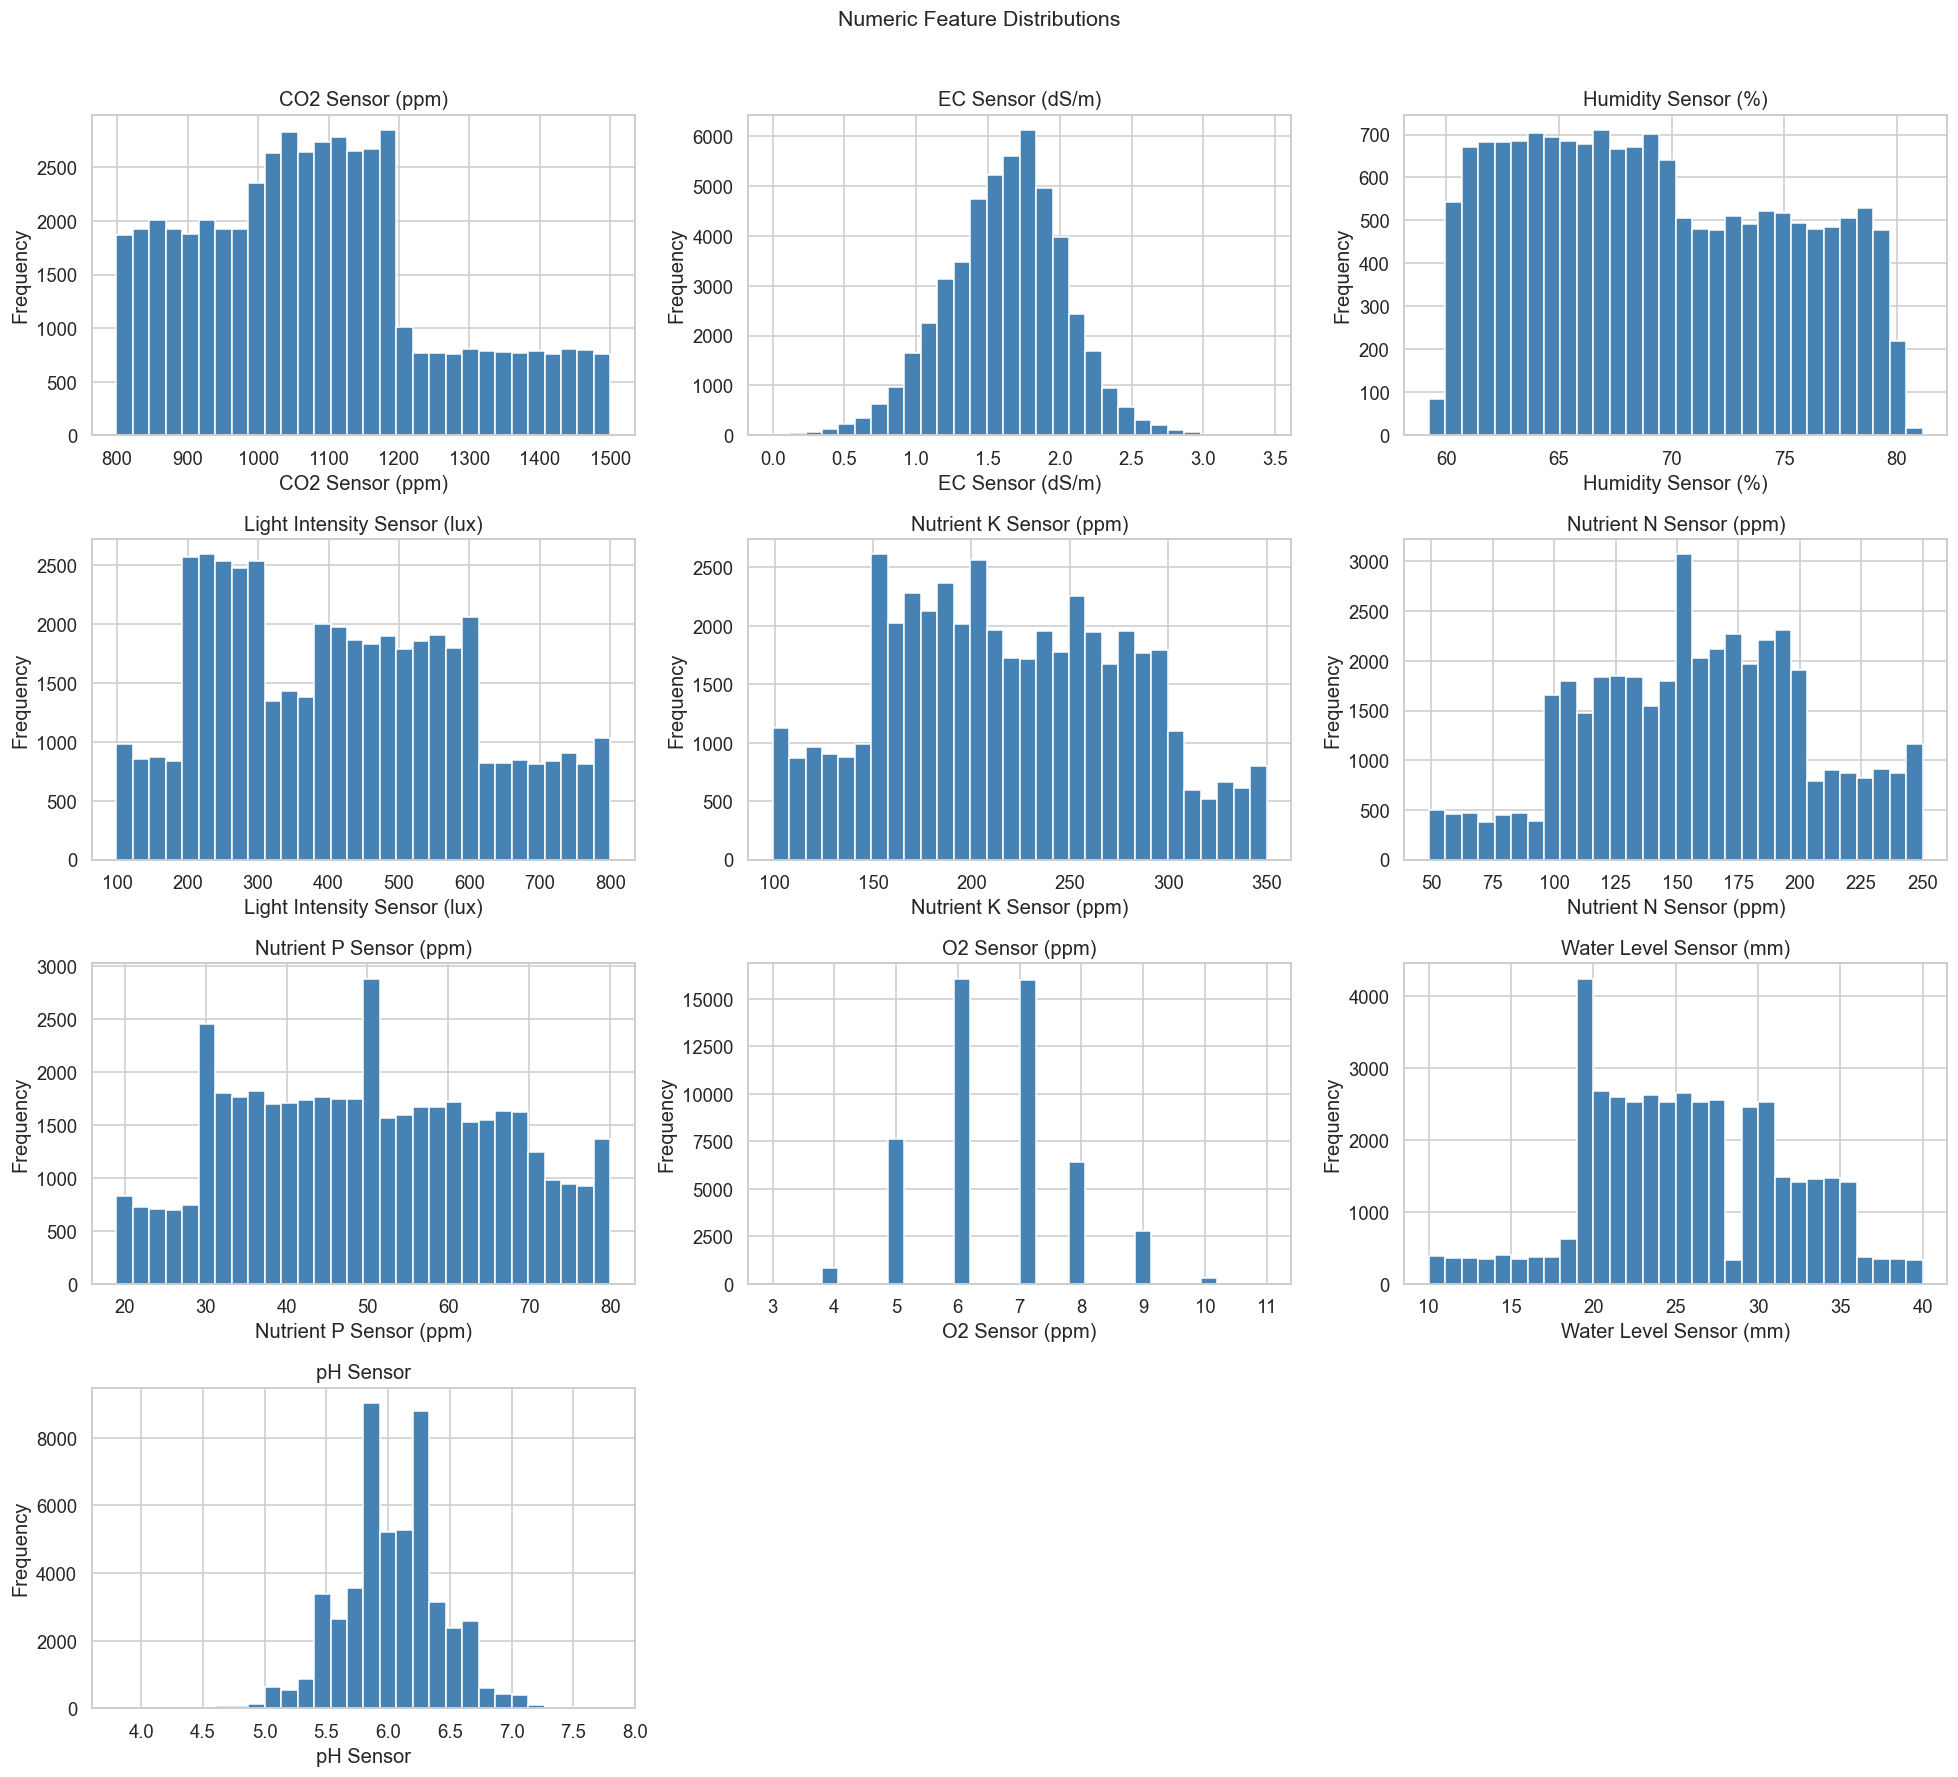

In [65]:
# ── 5. Numeric feature distributions ────────────────────────────────────────
# Includes nutrient cols (now numeric after §4c) and excludes the regression
# target. Temperature itself is examined separately in §4a.
num_cols = (
    df.select_dtypes(include='number')
      .columns
      .difference([TARGET_COLUMN])
      .tolist()
)
print(f'Numeric features ({len(num_cols)}): {num_cols}')

if num_cols:
    n = len(num_cols)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_cols):
        ax = axes[i]
        df[col].dropna().hist(ax=ax, bins=30, color='steelblue', edgecolor='white')
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

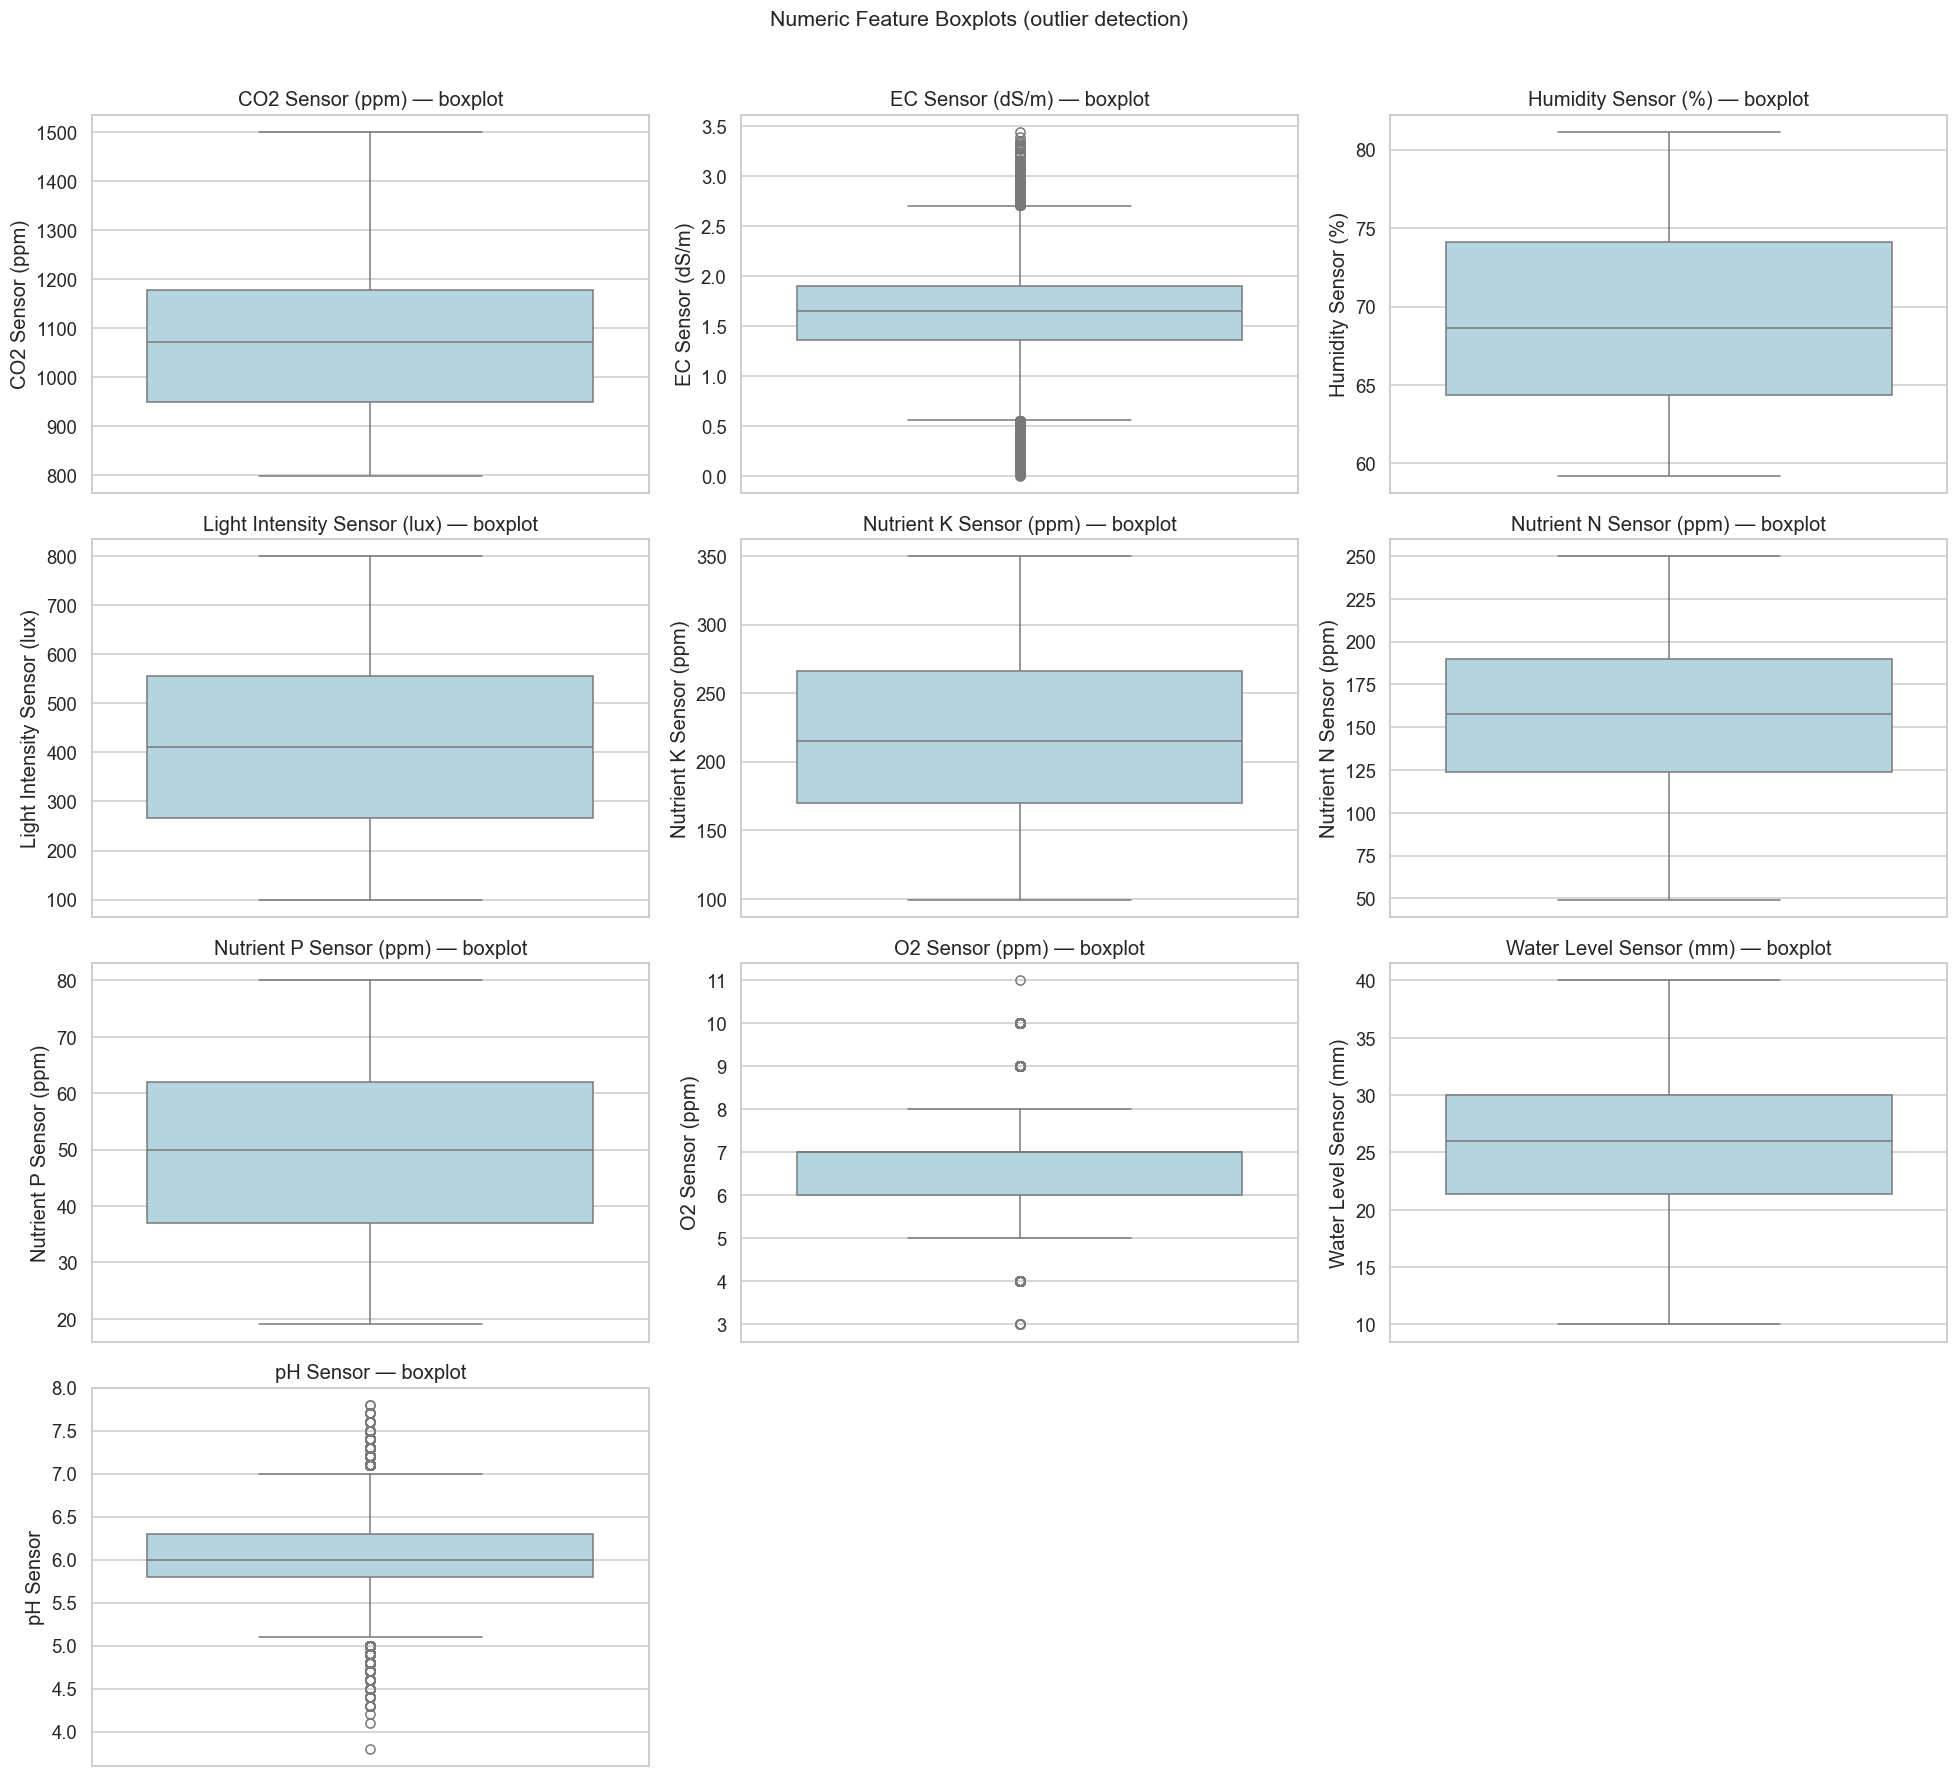

In [66]:
# Box plots to spot outliers
if num_cols:
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_cols):
        ax = axes[i]
        sns.boxplot(y=df[col], ax=ax, color='lightblue')
        ax.set_title(f'{col} — boxplot')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric Feature Boxplots (outlier detection)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

**Observations:**

- After §4c, **all three Nutrient columns are now numeric** and appear in `num_cols`. They sit in physically sensible ranges:
  - `Nutrient N`: ~49 – 250 ppm
  - `Nutrient P`: ~19 – 80 ppm
  - `Nutrient K`: ~99 – 350 ppm
- **Light Intensity Sensor (lux)** distribution is roughly uniform from ~99 to 800 lux — looks like the sensor saturates at 800 (the max value sits exactly at 800, with a hard upper edge). Worth flagging: any reading at 800 may represent "≥800", not exactly 800.
- **CO2, EC, O2, pH** are all roughly symmetric, near-Gaussian.
- **Water Level Sensor (mm)** has a sharp lower spike around 10 mm (`min = 10.00`) followed by a smoother distribution — likely a different sensor calibration or a calibration floor.
- **Boxplots show no remaining extreme outliers** after the §4c sign-flip repair. The previous −28 °C / −799 lux / −0.25 dS/m artefacts are gone.
- **No skew severe enough to require log-transform.** Most features are within 2–3× of their median.
- For the regression task, scaling (e.g. `StandardScaler`) is sufficient. No special transforms needed.

---
## 6. Categorical Feature Analysis

**Purpose:** check cardinality, rare-category prevalence, and unexpected values for each categorical feature. Drives encoding decisions (one-hot vs ordinal vs target encoding) and flags any further normalisation needed beyond what §4b/§4c already do.

Categorical features (4): ['Plant Stage', 'Plant Type', 'Previous Cycle Plant Type', 'System Location Code']


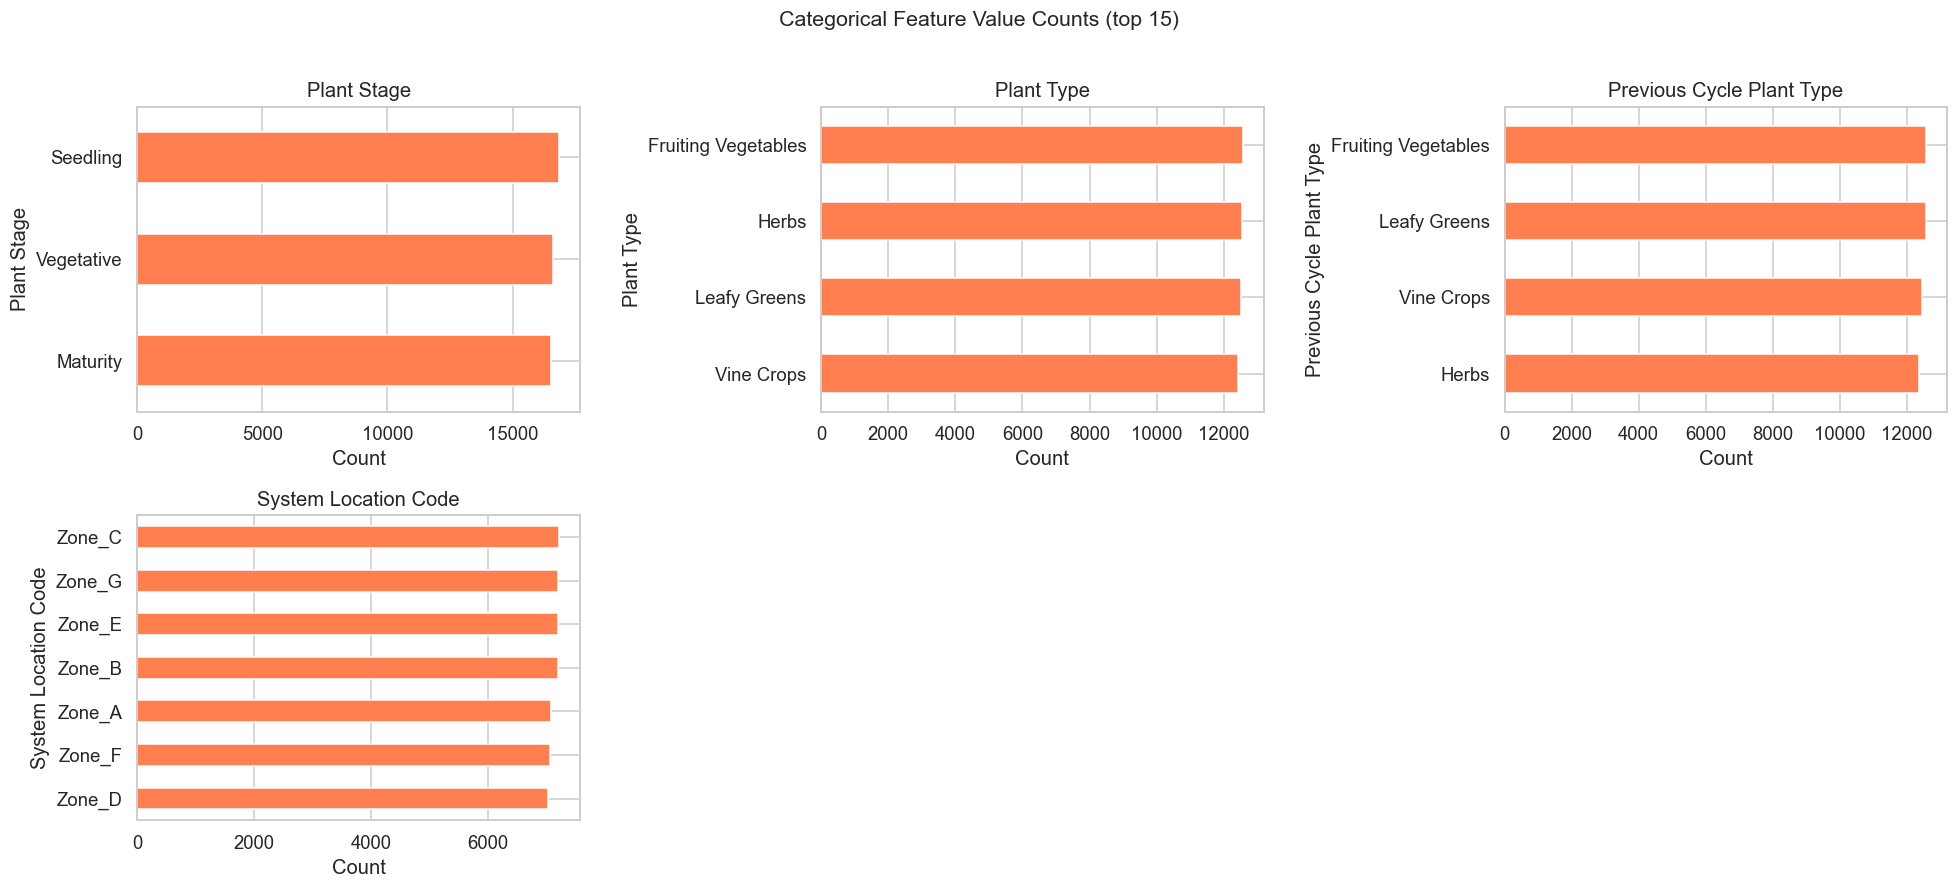

In [67]:
# Categorical columns excluding the composite target (which is itself derived from two of these).
# Include 'string' dtype alongside object/category to silence the pandas FutureWarning.
cat_cols = (
    df.select_dtypes(include=['object', 'category', 'string'])
      .columns
      .difference([TARGET_COLUMN, TARGET_CLASSIFICATION])
      .tolist()
)
print(f'Categorical features ({len(cat_cols)}): {cat_cols}')

if cat_cols:
    n = len(cat_cols)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_cols):
        ax = axes[i]
        top_values = df[col].value_counts().head(15)
        top_values.plot.barh(ax=ax, color='coral')
        ax.set_title(col)
        ax.set_xlabel('Count')
        ax.invert_yaxis()

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Categorical Feature Value Counts (top 15)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [68]:
# Cardinality summary
if cat_cols:
    cardinality = df[cat_cols].nunique().rename('unique_values').to_frame()
    cardinality['example_values'] = [df[c].dropna().unique()[:5].tolist() for c in cat_cols]
    display(cardinality)

,unique_values,example_values
Plant Stage,3,"[Maturity, Vegetative, Seedling]"
Plant Type,4,"[Vine Crops, Herbs, Fruiting Vegetables, Leafy..."
Previous Cycle Plant Type,4,"[Herbs, Vine Crops, Leafy Greens, Fruiting Veg..."
System Location Code,7,"[Zone_D, Zone_G, Zone_F, Zone_B, Zone_C]"


**Observations:**

- **`System Location Code`** — 7 zones (Zone_A through Zone_G), evenly distributed (8,062 to 8,296 per zone, ~1.03× balance). No rare or unexpected values. Safe to one-hot encode with no dropping.
- **`Previous Cycle Plant Type`** — 4 categories matching the current `Plant Type` set (Fruiting Vegetables, Herbs, Leafy Greens, Vine Crops), also evenly distributed (~14,300 per category). Already clean — no casing variants.
- **`Plant Type`** — 4 categories after the §4b normalisation (Fruiting Vegetables, Herbs, Leafy Greens, Vine Crops).
- **`Plant Stage`** — 3 categories after §4b (Seedling, Vegetative, Maturity).
- **No high-cardinality columns.** All categoricals are safe for one-hot encoding without dimensionality concerns: total dummy-column count is ≤17.
- **No unknown / rare categories** to worry about at train/test time — the 4 plant types and 3 stages cover the full categorical space.
- **Encoding choice:** one-hot for tree models is fine. For ordinal-aware models on `Plant Stage`, consider ordinal encoding (Seedling=0, Vegetative=1, Maturity=2) since stages have a natural growth order.

---
## 7. Correlation Analysis

**Purpose:** identify multicollinearity (which affects linear models' coefficient stability) and rank features by their linear association with the regression target. Spearman is checked alongside Pearson in §8 to catch any monotone-but-non-linear relationships missed here.

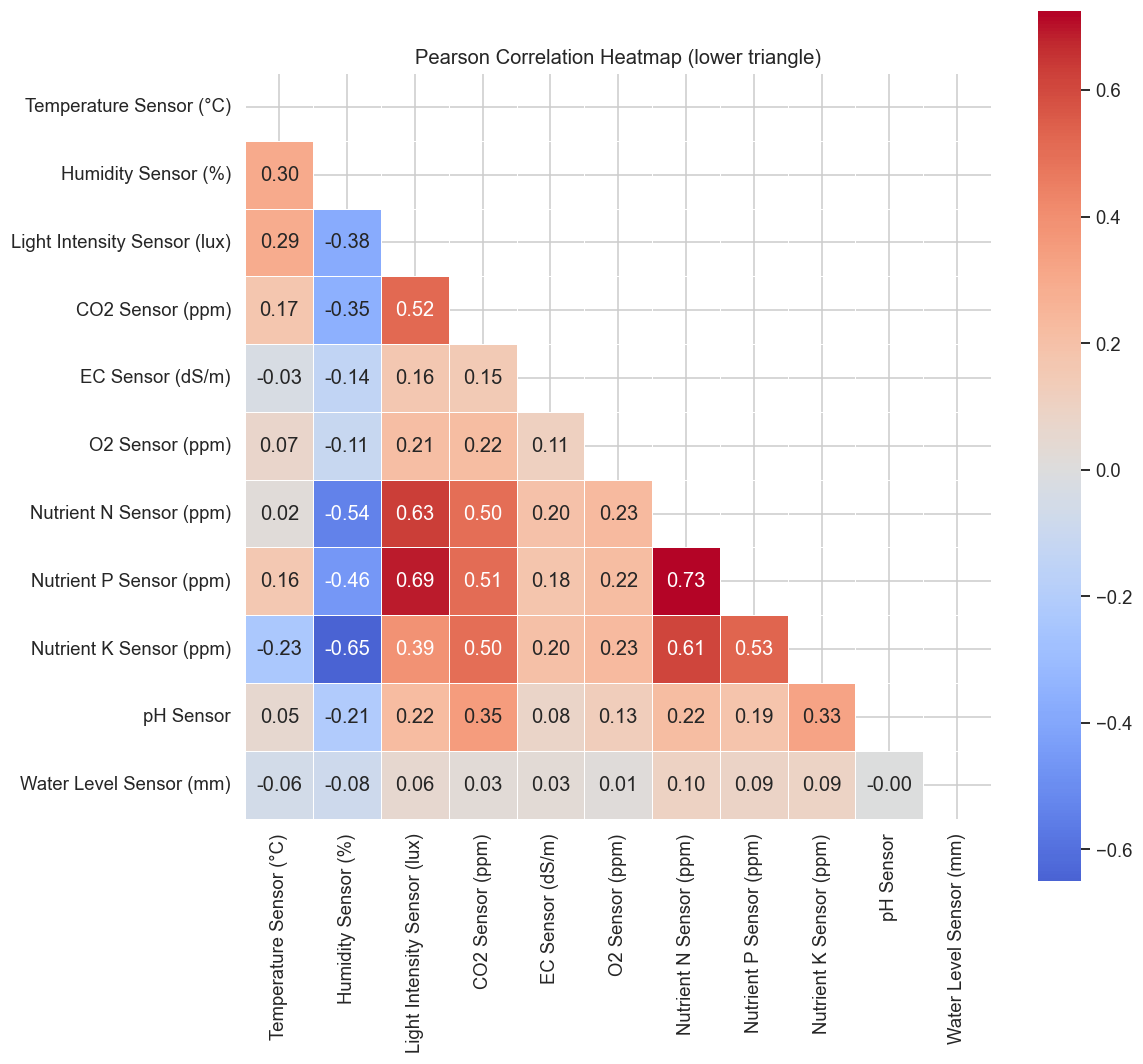

High-correlation pairs (|r| > 0.5):


,feature_a,feature_b,r
0,Nutrient P Sensor (ppm),Nutrient N Sensor (ppm),0.725584
1,Nutrient P Sensor (ppm),Light Intensity Sensor (lux),0.688269
2,Nutrient K Sensor (ppm),Humidity Sensor (%),-0.650025
3,Nutrient N Sensor (ppm),Light Intensity Sensor (lux),0.632131
4,Nutrient K Sensor (ppm),Nutrient N Sensor (ppm),0.607586
5,Nutrient N Sensor (ppm),Humidity Sensor (%),-0.542409
6,Nutrient K Sensor (ppm),Nutrient P Sensor (ppm),0.531533
7,CO2 Sensor (ppm),Light Intensity Sensor (lux),0.519747
8,Nutrient P Sensor (ppm),CO2 Sensor (ppm),0.510130
9,Nutrient K Sensor (ppm),CO2 Sensor (ppm),0.503522



Feature correlation with Temperature Sensor (°C):


,pearson_with_temp
Humidity Sensor (%),+0.300
Light Intensity Sensor (lux),+0.294
Nutrient K Sensor (ppm),-0.231
CO2 Sensor (ppm),+0.173
Nutrient P Sensor (ppm),+0.161
O2 Sensor (ppm),+0.071
Water Level Sensor (mm),-0.062
pH Sensor,+0.049
EC Sensor (dS/m),-0.030
Nutrient N Sensor (ppm),+0.017


In [69]:
# Pearson correlation on the full numeric set (includes Temperature target and nutrients
# after §4c coercion). Lower triangle only; pairs with |r| > 0.5 listed below.
corr_cols = df.select_dtypes(include='number').columns.tolist()

if len(corr_cols) > 1:
    corr = df[corr_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(max(8, len(corr_cols)), max(6, len(corr_cols) - 1)))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, linewidths=0.5,
        ax=ax, square=True,
    )
    ax.set_title('Pearson Correlation Heatmap (lower triangle)')
    plt.tight_layout()
    plt.show()

    # Pairs with |r| > 0.5 (excluding self) — dropna() filters out the masked upper triangle
    high_corr = (
        corr.where(~mask & (corr.abs() > 0.5))
            .stack()
            .dropna()
            .reset_index()
            .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'r'})
            .sort_values('r', key=abs, ascending=False)
            .reset_index(drop=True)
    )
    if not high_corr.empty:
        print('High-correlation pairs (|r| > 0.5):')
        display(high_corr)
    else:
        print('No feature pairs with |r| > 0.5.')

    # Correlation with the regression target only — full ranking
    target_corr = (
        corr[TARGET_REGRESSION]
        .drop(TARGET_REGRESSION)
        .to_frame('pearson_with_temp')
        .assign(abs_r=lambda d: d['pearson_with_temp'].abs())
        .sort_values('abs_r', ascending=False)
        .drop(columns='abs_r')
    )
    print(f'\nFeature correlation with {TARGET_REGRESSION}:')
    display(target_corr.style.format({'pearson_with_temp': '{:+.3f}'}))
else:
    print('Not enough numeric columns for a correlation heatmap.')

**Observations:**

**Correlation with the regression target (Temperature):**

| Feature | Pearson r |
|---|---|
| `Humidity Sensor (%)` | **+0.30** |
| `Light Intensity Sensor (lux)` | **+0.29** |
| `Nutrient K Sensor (ppm)` | **−0.23** |
| `CO2 Sensor (ppm)` | +0.17 |
| `Nutrient P Sensor (ppm)` | +0.16 |
| O2, pH, Water, EC, Nutrient N | < 0.10 (weak) |

- No single feature is a strong predictor. The model will need to combine multiple weak signals plus the strong categorical drivers (`Plant Type`, `Plant Stage` — see §8a) to do useful work.
- **Light Intensity jumped from +0.22 (§8 draft) to +0.29 after the §4c `abs()` repair** — a reminder of how much the negative sensor readings were polluting earlier estimates.
- `Nutrient N` is essentially uncorrelated with Temperature (r=+0.02). Drop or keep depending on tree-model behaviour; linear models should drop it.

**Multicollinearity — strong feature pairs (|r| > 0.5):**

| Pair | r |
|---|---|
| `Nutrient P` ↔ `Nutrient N` | **+0.73** |
| `Nutrient P` ↔ `Light Intensity` | **+0.69** |
| `Nutrient K` ↔ `Humidity` | **−0.65** |
| `Nutrient N` ↔ `Light Intensity` | +0.63 |
| `Nutrient K` ↔ `Nutrient N` | +0.61 |
| `Nutrient N` ↔ `Humidity` | −0.54 |
| `Nutrient K` ↔ `Nutrient P` | +0.53 |
| `CO2` ↔ `Light Intensity` | +0.52 |
| `Nutrient P` ↔ `CO2` | +0.51 |
| `Nutrient K` ↔ `CO2` | +0.50 |

- **The three nutrient columns are tightly intercorrelated** (all pairwise r between 0.53 and 0.73). For linear models this is multicollinearity — consider PCA, partial-least-squares, or dropping two of three. For tree models it's harmless but redundant feature engineering.
- **Nutrients also correlate strongly with Light Intensity and CO₂** — likely because all four reflect the same underlying "growth-stage / lifecycle" latent variable, which is itself captured by `Plant Stage`. After conditioning on `Plant Stage`, much of this correlation should disappear.
- **Humidity is inversely correlated with most things** (Nutrients, Light, CO₂). Combined with its 67.6% missingness, the case for dropping Humidity from the regression model strengthens — its signal is partially redundant with features that are present in every row.
- **`Water Level` and `O2`** are nearly uncorrelated with everything (|r| < 0.15 with all features). Likely low-value features.

**Implication for modelling:**
- For tree-based regression (XGBoost, LightGBM, RandomForest), no action needed — they handle multicollinearity natively.
- For linear regression / Ridge / Lasso, drop or PCA the Nutrient cluster. A regularised model with all 10 features will still work but coefficients will be unstable.

---
## 8. Bivariate Analysis (Features vs Target)

**Purpose:** examine each feature's relationship with each target. For the regression target, this means scatter / hexbin visualisations and correlation with Temperature. For the classification target, this means per-class distributions of numeric features and contingency proportions for categorical features. Identifies the strongest predictors and any features safe to drop.

Two perspectives:

- **8a — Features vs Temperature** (regression): hexbin scatter, Pearson + Spearman correlation with the target. Temperature is `abs()`-repaired in §4c so sign-flipped readings don't dominate.
- **8b — Features vs Plant Type-Stage** (classification): per-class distributions for numeric features (boxplot) and contingency proportions for categorical features.

### 8a. Numeric features vs Temperature (regression)

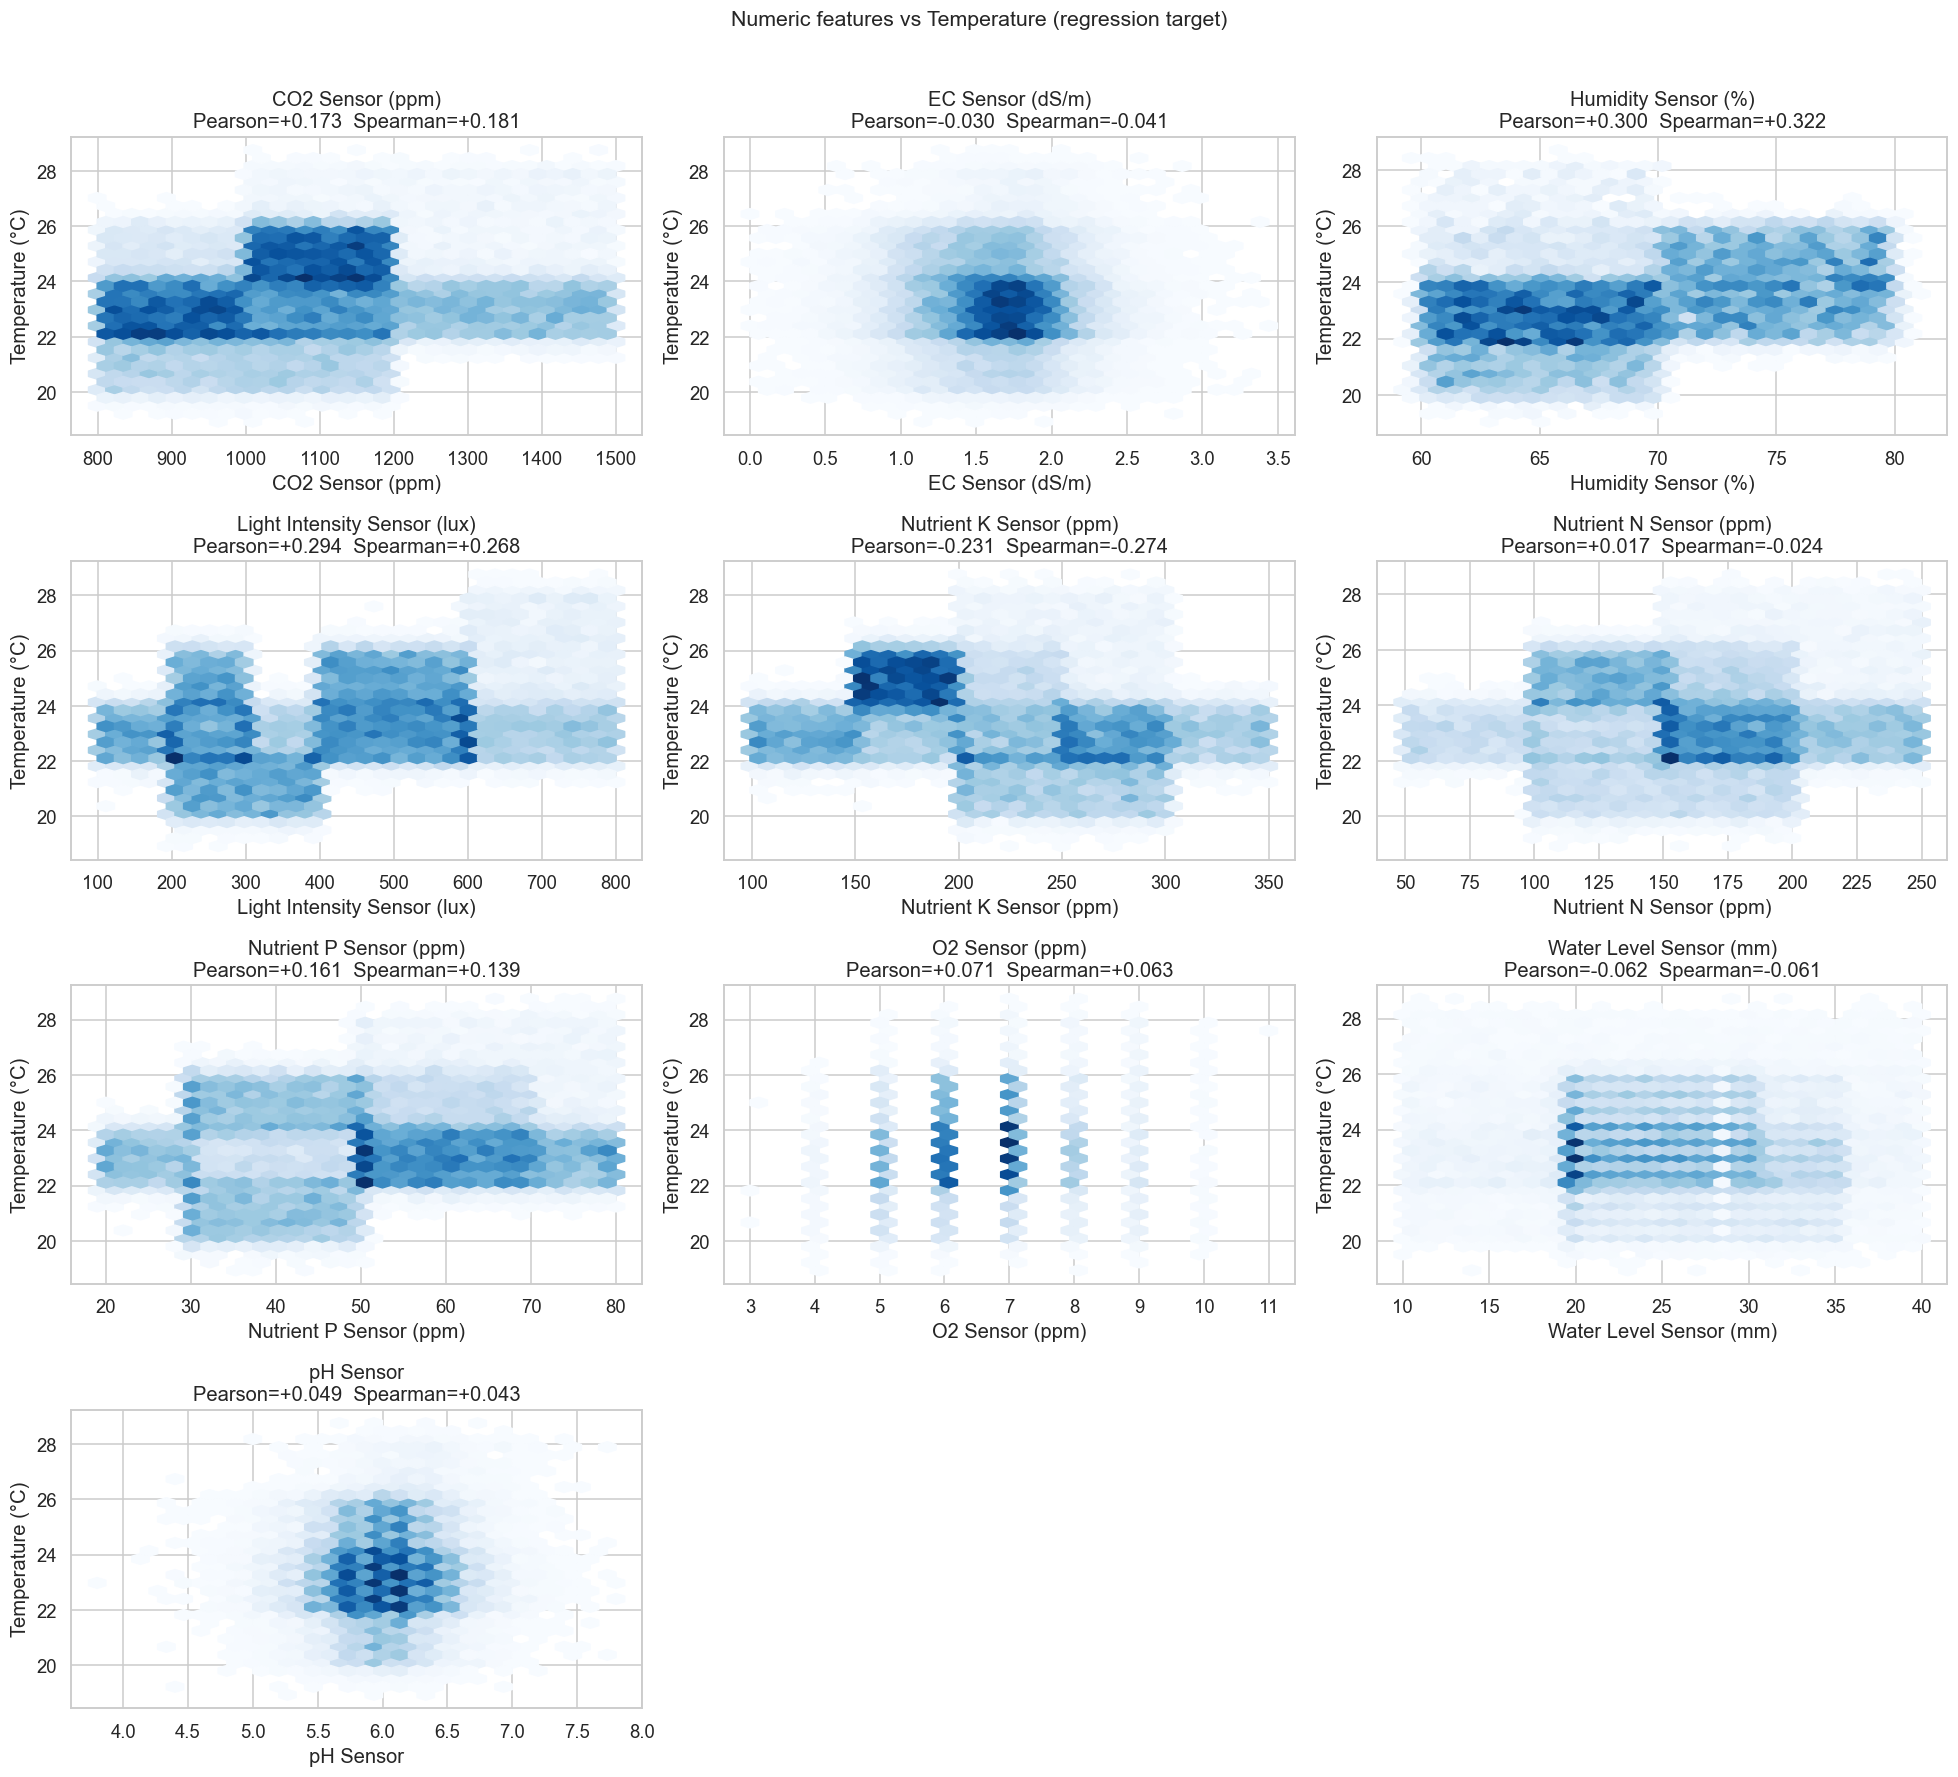

,feature,pearson,spearman,n
2,Humidity Sensor (%),+0.300,+0.322,"13,691"
3,Light Intensity Sensor (lux),+0.294,+0.268,"39,250"
4,Nutrient K Sensor (ppm),-0.231,-0.274,"39,514"
0,CO2 Sensor (ppm),+0.173,+0.181,"42,416"
6,Nutrient P Sensor (ppm),+0.161,+0.139,"38,005"
7,O2 Sensor (ppm),+0.071,+0.063,"42,416"
8,Water Level Sensor (mm),-0.062,-0.061,"36,015"
9,pH Sensor,+0.049,+0.043,"42,416"
1,EC Sensor (dS/m),-0.030,-0.041,"42,416"
5,Nutrient N Sensor (ppm),+0.017,-0.024,"34,907"


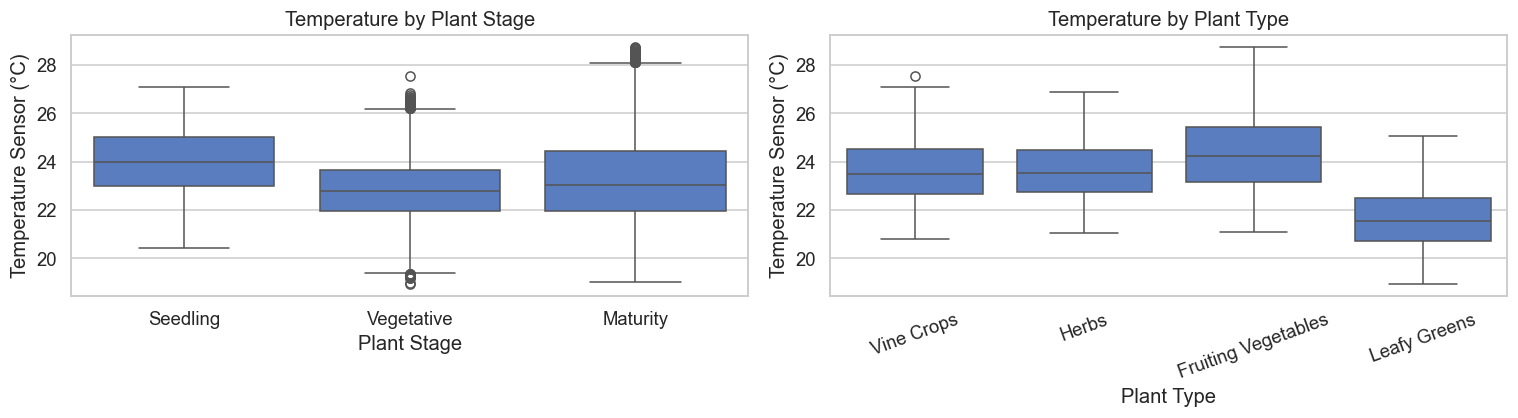

In [70]:
# ── 8a. Numeric features vs Temperature (regression) ───────────────────────
# Use abs()-repaired temperature for the regression bivariate analysis
df_reg = df.copy()
df_reg[TARGET_REGRESSION] = df_reg[TARGET_REGRESSION].abs()
df_reg = df_reg.dropna(subset=[TARGET_REGRESSION])

num_features = [c for c in num_cols if c != TARGET_REGRESSION]

if num_features:
    n = len(num_features)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    corr_rows = []
    for i, col in enumerate(num_features):
        sub = df_reg[[col, TARGET_REGRESSION]].dropna()
        r_p = sub[col].corr(sub[TARGET_REGRESSION])
        r_s = sub[col].corr(sub[TARGET_REGRESSION], method='spearman')
        corr_rows.append({'feature': col, 'pearson': r_p, 'spearman': r_s, 'n': len(sub)})

        axes[i].hexbin(sub[col], sub[TARGET_REGRESSION], gridsize=30, cmap='Blues', mincnt=1)
        axes[i].set_title(f'{col}\nPearson={r_p:+.3f}  Spearman={r_s:+.3f}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Temperature (°C)')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric features vs Temperature (regression target)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    corr_df = pd.DataFrame(corr_rows).sort_values('pearson', key=abs, ascending=False)
    display(corr_df.style.format({'pearson': '{:+.3f}', 'spearman': '{:+.3f}', 'n': '{:,}'}))

# Temperature also varies by the categorical Plant Type / Plant Stage columns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df_reg, x='Plant Stage', y=TARGET_REGRESSION, ax=axes[0],
            order=['Seedling', 'Vegetative', 'Maturity'])
axes[0].set_title('Temperature by Plant Stage')
sns.boxplot(data=df_reg, x='Plant Type', y=TARGET_REGRESSION, ax=axes[1])
axes[1].set_title('Temperature by Plant Type')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 8b. Features vs Plant Type-Stage (classification)

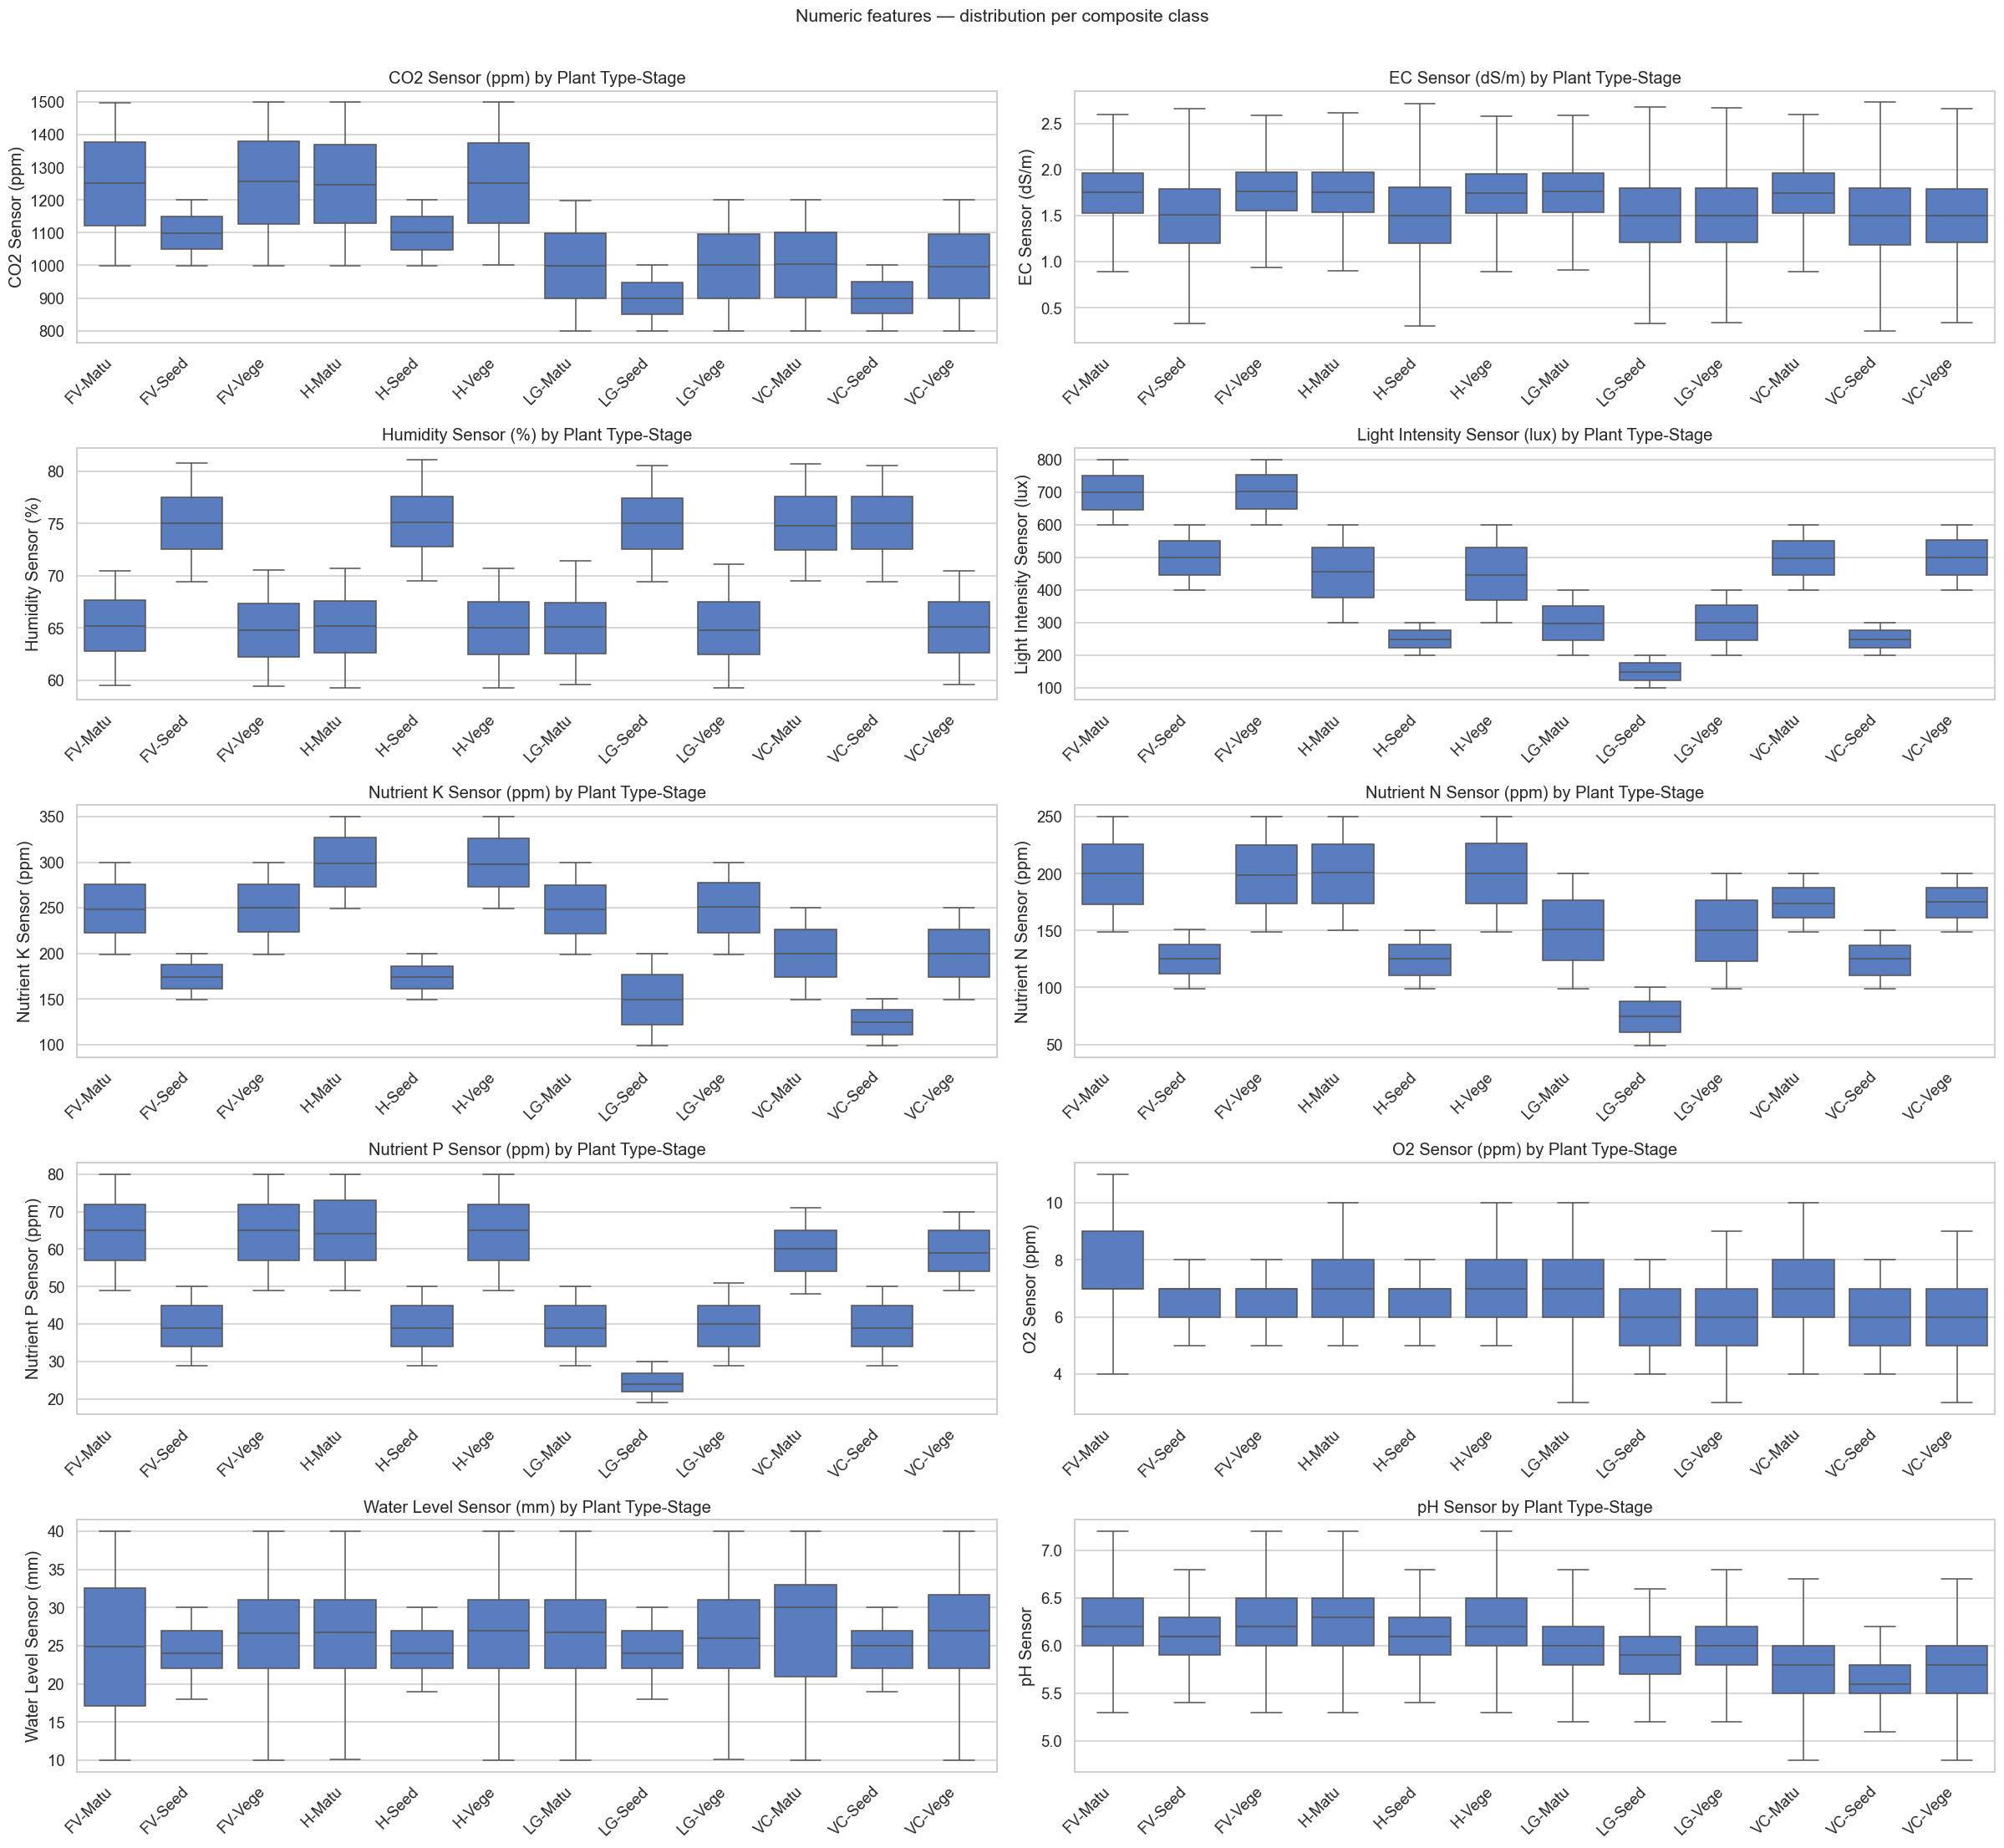

Class label legend:
  FV-Matu    = Fruiting Vegetables — Maturity
  FV-Seed    = Fruiting Vegetables — Seedling
  FV-Vege    = Fruiting Vegetables — Vegetative
  H-Matu     = Herbs — Maturity
  H-Seed     = Herbs — Seedling
  H-Vege     = Herbs — Vegetative
  LG-Matu    = Leafy Greens — Maturity
  LG-Seed    = Leafy Greens — Seedling
  LG-Vege    = Leafy Greens — Vegetative
  VC-Matu    = Vine Crops — Maturity
  VC-Seed    = Vine Crops — Seedling
  VC-Vege    = Vine Crops — Vegetative


In [71]:
# ── 8b-i. Numeric features distribution by composite class ─────────────────
# Abbreviate the 12 composite class names so x-axis labels stay readable.
# "Fruiting Vegetables — Seedling"  → "FV-Seed"
# "Leafy Greens — Maturity"        → "LG-Matu"
def _abbrev_class(name):
    type_part, stage = name.split(' — ')
    type_abbrev = ''.join(w[0] for w in type_part.split())
    return f'{type_abbrev}-{stage[:4]}'

class_order = sorted(df[TARGET_CLASSIFICATION].unique())
class_labels = [_abbrev_class(c) for c in class_order]

if num_features:
    n = len(num_features)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(11 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(num_features):
        sns.boxplot(
            data=df.dropna(subset=[col]),
            x=TARGET_CLASSIFICATION, y=col,
            order=class_order, ax=axes[i], showfliers=False,
        )
        axes[i].set_title(f'{col} by {TARGET_CLASSIFICATION}')
        axes[i].set_xticks(range(len(class_labels)))
        axes[i].set_xticklabels(class_labels, rotation=45, ha='right')
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Numeric features — distribution per composite class', fontsize=14, y=1.005)
    plt.tight_layout()
    plt.show()

# Legend mapping the abbreviations to the full names (printed once)
print('Class label legend:')
for full, short in zip(class_order, class_labels):
    print(f'  {short:<10} = {full}')

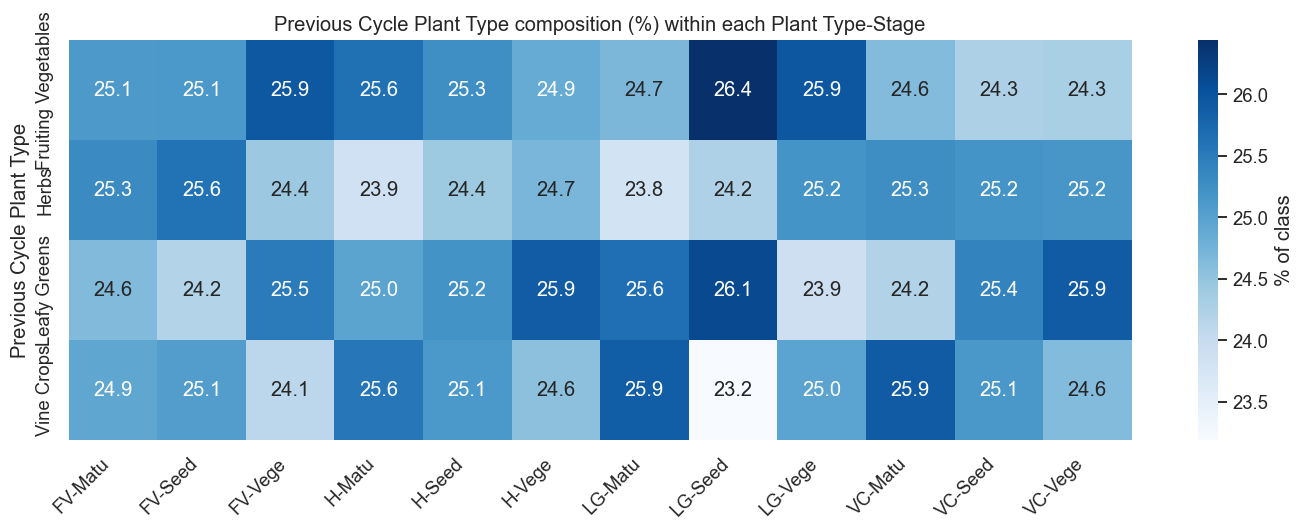

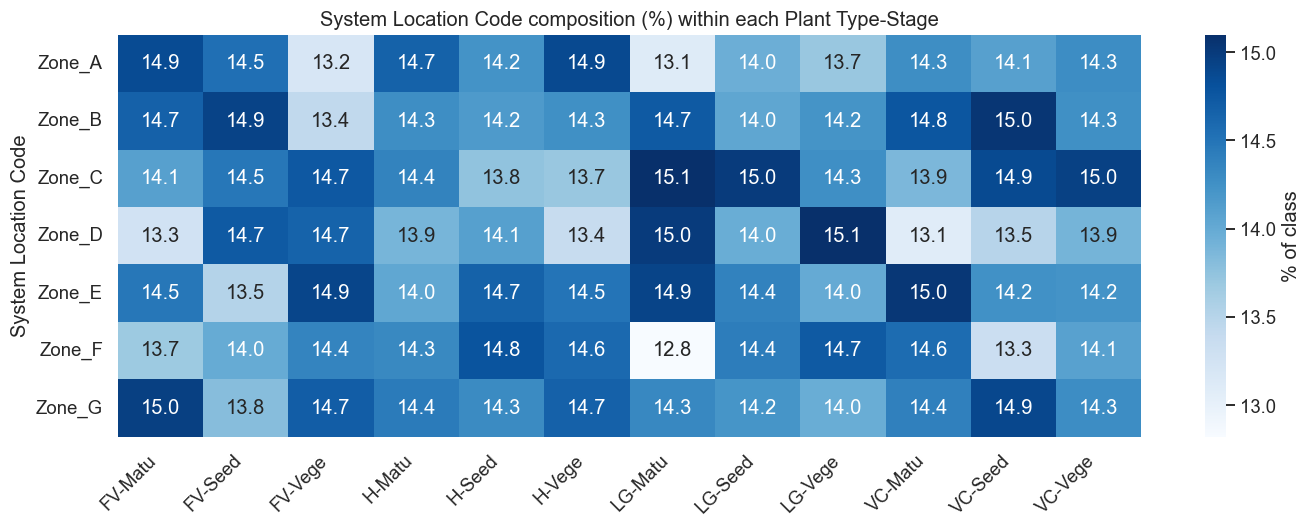

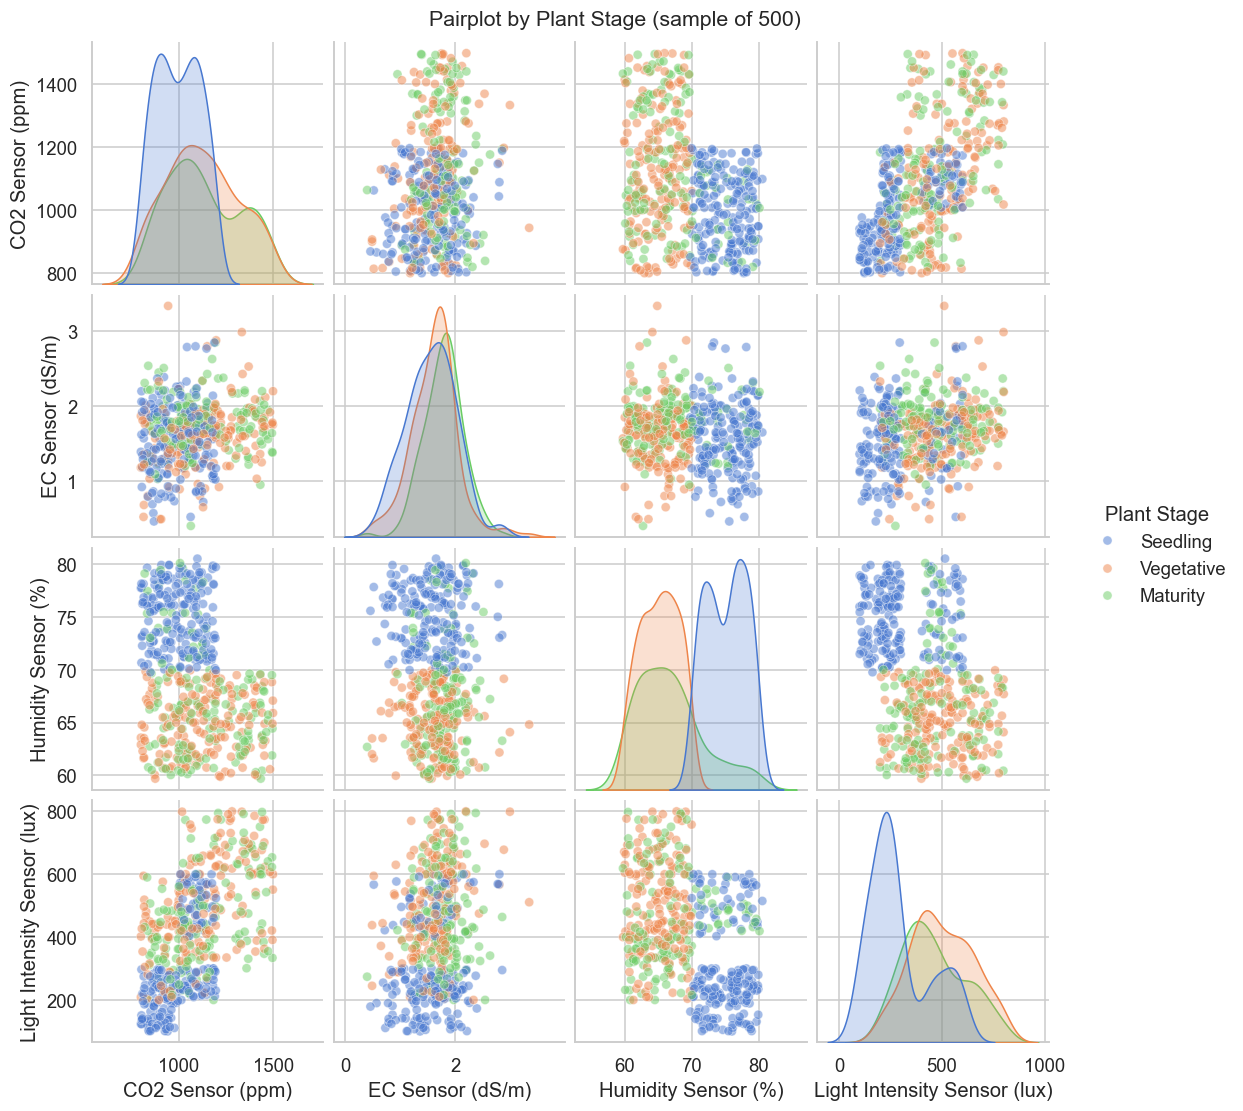

In [72]:
# ── 8b-ii. Categorical features vs composite class ─────────────────────────
# Skip Plant Type / Plant Stage (they're the source columns), skip the target itself.
cat_features = [
    c for c in cat_cols
    if c not in {'Plant Type', 'Plant Stage', TARGET_CLASSIFICATION}
]

for col in cat_features:
    ct = pd.crosstab(df[col], df[TARGET_CLASSIFICATION], normalize='columns') * 100
    ct.columns = [_abbrev_class(c) for c in ct.columns]

    # Hardcoded minimum height (5") so heatmaps with few rows stay readable
    fig, ax = plt.subplots(figsize=(13, max(5, 0.6 * ct.shape[0])))
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues',
                cbar_kws={'label': '% of class'}, ax=ax)
    ax.set_title(f'{col} composition (%) within each {TARGET_CLASSIFICATION}')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ── 8b-iii. Compact pairplot using Plant Stage (3 classes) as hue ──────────
# Full 12-class composite is too cluttered for a pairplot; Plant Stage shows
# the strongest multivariate separation in the underlying components.
PAIRPLOT_COLS = num_features[:4]
if len(PAIRPLOT_COLS) >= 2 and 'Plant Stage' in df.columns:
    sample = df[PAIRPLOT_COLS + ['Plant Stage']].dropna().sample(
        n=min(500, len(df)), random_state=42,
    )
    g = sns.pairplot(sample, hue='Plant Stage', plot_kws={'alpha': 0.5}, diag_kind='kde',
                     hue_order=['Seedling', 'Vegetative', 'Maturity'])
    g.fig.suptitle('Pairplot by Plant Stage (sample of 500)', y=1.01, fontsize=14)
    plt.show()

**Observations:**

**8a — Features vs Temperature (regression)**

- Strongest linear predictors of Temperature (Pearson on §4c-cleaned data):
  - `Humidity Sensor (%)` — **+0.30** (Spearman +0.32). Real signal, but feature is sparse: only ~32% of cleaned rows have humidity present.
  - `Light Intensity Sensor (lux)` — **+0.29**. Jumped from +0.22 before §4c repaired the sign-flipped lux readings.
  - `Nutrient K Sensor (ppm)` — **−0.23**.
  - `CO2 Sensor (ppm)` — **+0.17**.
- Weak predictors: `pH` (+0.05), `O2` (+0.07), `Water Level` (−0.06), `EC` (−0.03), `Nutrient N` (+0.02). Spearman ≈ Pearson for all — no nonlinear monotone relationship is hiding behind a low Pearson.
- **Categorical drivers are larger than any single numeric feature:**
  - `Plant Type` shifts mean Temperature by ~**2.7 °C** (Leafy Greens 21.7 → Fruiting Vegetables 24.4).
  - `Plant Stage` shifts mean Temperature by ~**1.2 °C** (Vegetative 22.8 → Seedling 24.0).
  - One-hot encoding both will likely give a tree-based model more lift than any single sensor reading. This is consistent with the bimodal Temperature distribution observed in §4a — the two modes are the per-Plant-Type setpoints.

**8b — Features vs Plant Type-Stage (classification)**

- Numeric features show clear class separation — boxplots reveal distinct centres per composite class. `CO2`, `Light Intensity`, and `pH` look especially discriminative; e.g. Leafy Greens classes sit at ~900 ppm CO₂ while Fruiting Vegetables / Herbs classes sit at ~1,100 ppm.
- **`System Location Code` is essentially non-informative for this target** — contingency proportions hover at ~13–15% across all 7 zones for every composite class. Zones host different crops uniformly. Safe to drop or keep as a low-value feature.
- **`Previous Cycle Plant Type` is also uninformative** — heatmap proportions sit at **23.4-26.4% across all 12 composite classes**, indistinguishable from a uniform 25% (4 prev-cycle types × 25%). Previous cycle is statistically independent of current Plant Type-Stage. Drop or keep as a low-value feature, same as `System Location Code`.
- The Plant Stage pairplot shows the cleanest multivariate separation along Light Intensity and CO₂ — those two features alone may carry most of the classification signal.
- **For the classification model:** standard scaling + one-hot on the relevant features (i.e. sensor columns; both `System Location Code` and `Previous Cycle Plant Type` can be safely dropped). 12-class composite as the label. No class weighting needed (balance was 1.07× per §4b).

---
## 9. Key Findings & Hypotheses

### Data Quality

- **Two prediction tasks**, not one: regression on `Temperature Sensor (°C)` and classification on the composite `Plant Type-Stage` (constructed in §4b from normalised `Plant Type` × `Plant Stage`).
- **7,489 full-row duplicates (13.0%)** dropped in §4c. Almost certainly a synthetic-data-generation artefact rather than a real measurement collision.
- **Sign-flipped sensor readings** affect three columns and were repaired via `abs()` in §4c. Without this, the regression target alone had 1,252 implausible negative values; Light Intensity had another 1,385. Assumption justified in the §4c callout.
- **Nutrient N / P / K columns are stored as strings** (some carry a `' ppm'` suffix). Coerced to numeric in §4c with `pd.to_numeric(errors='coerce')`; ~228–262 unparseable values per column become `NaN`.
- **Casing / whitespace variants** inflate `Plant Type` from 4 to 12 unique values and `Plant Stage` from 3 to 9. Normalised in §4b — without this step the composite target would have ~108 spurious classes.
- **Humidity Sensor is 67.6% missing** — the single biggest data-quality issue. Keep with a `humidity_present` indicator or drop entirely; do not naively impute on this much missingness.
- **No row is fully empty.** Listwise deletion on the cleaned feature set is overly aggressive.

### Most Informative Features

**For Temperature regression** (correlation magnitudes, after §4c cleaning):

| Rank | Feature | Pearson r with Temp |
|---|---|---|
| 1 | `Plant Type` (categorical) | up to ~2.7 °C class shift |
| 2 | `Plant Stage` (categorical) | up to ~1.2 °C class shift |
| 3 | `Humidity Sensor (%)` | +0.30 (but 67.6% missing) |
| 4 | `Light Intensity Sensor (lux)` | +0.29 |
| 5 | `Nutrient K Sensor (ppm)` | −0.23 |
| 6 | `CO2 Sensor (ppm)` | +0.17 |
| 7 | `Nutrient P Sensor (ppm)` | +0.16 |

Temperature is **bimodal** (~22 °C and ~24 °C peaks) reflecting the per-Plant-Type setpoints — Plant Type alone explains most of the structure.

**For Plant Type-Stage classification:**
- `CO2`, `Light Intensity`, `pH` show clear per-class separation.
- `Plant Stage` × sensor pairplot suggests Light + CO₂ alone may capture most of the signal.
- **Both `System Location Code` and `Previous Cycle Plant Type` are uninformative** — distributions hover at 13–15% and 23–26% respectively (i.e. uniform across classes). Both safe to drop.
- All three nutrient columns separate cleanly between Leafy Greens classes and the rest.

### Hypotheses for Modelling

1. **Temperature is mostly explained by Plant Type + Plant Stage**, with sensor readings providing residual lift. The bimodal Temperature distribution (§4a) directly reflects per-Plant-Type setpoints (§8a). A model trained on the categorical features alone should already explain a meaningful portion of variance.
2. **The 12-class classification problem is well-conditioned**: balanced classes (1.07× imbalance), strong per-class signal in 3+ sensors, and only 4 underlying types × 3 stages — no rare-class problem.
3. **Multicollinearity among Nutrients + Light + CO₂ reflects a "growth stage" latent variable.** Conditioning on `Plant Stage` should dissolve most of the |r| > 0.5 pairs, so tree-based models with both nutrients AND stage as inputs will be redundant but harmless.
4. **Humidity, despite the strongest raw correlation with Temperature, may underperform `Light Intensity` as a feature** because of its 67.6% missingness. A simple ablation (drop humidity, retrain) is worth running.
5. **`System Location Code` and `Previous Cycle Plant Type` are nuisance features** — zone independence and previous-cycle independence are confirmed by §8b-ii heatmaps. Drop both.

### Preprocessing Decisions

| Decision | Rationale |
|---|---|
| Drop full-row duplicates | 7,489 exact duplicates (13%); synthetic-data artefact |
| Normalise `Plant Type` and `Plant Stage` (`strip().title()`) | Casing / whitespace variants inflate cardinality 3×; without this, the composite target has ~108 spurious classes |
| Construct composite `Plant Type-Stage` target | Brief specifies the combined label as the classification target |
| Coerce `Nutrient N / P / K` with `pd.to_numeric(errors='coerce')` | Strings with ' ppm' suffix break any numeric model |
| `abs()`-repair Temperature, Light Intensity, EC | Negative values are physically impossible and match the magnitude of legitimate values; assumption documented in §4c |
| Drop rows with missing Temperature for regression task | Cannot impute the target itself; 15% loss is acceptable |
| Median-impute remaining sensors, grouped by `Plant Type-Stage` | Plant context predicts sensor values better than overall median |
| Add `humidity_present` missing-indicator feature | Captures the MAR/MNAR signal cheaply |
| **Drop** `System Location Code` and `Previous Cycle Plant Type` | Confirmed uninformative in §8b-ii (uniform proportions across all 12 classes) |
| One-hot `Plant Type`, `Plant Stage` | Both ≤4 categories; no high-cardinality risk |
| Ordinal-encode `Plant Stage` for ordinal-aware models | Stage has natural order Seedling < Vegetative < Maturity |
| Standardise numeric features for linear / KNN / NN models | Sensors span very different scales (lux 0–800 vs pH 3.8–7.8); tree models don't need this |
| No class weighting / SMOTE for the classification target | Balance is 1.07× — already balanced |

### Suggested Models

- **Regression (Temperature):**
  1. Gradient-boosted trees (XGBoost or LightGBM) — handles multicollinearity, mixed types, and missingness natively. Will exploit the Plant-Type partition that drives Temperature's bimodality.
  2. Linear baseline (Ridge) on a reduced feature set (drop two of three Nutrients, drop Humidity if missingness blocks it). Note: linear model will smear the two Temperature modes into a single bias — expect tree models to dominate.
- **Classification (Plant Type-Stage):**
  1. Gradient-boosted trees with `multiclass:softmax` objective.
  2. Logistic regression baseline with one-hot + scaled numerics for interpretability.

### Next Steps

- [ ] Update `src/settings.py` with the cleaned column lists from §6 + §4c.
- [ ] Encode `§4c` cleaning as a reusable preprocessing step in `src/feature_engineering.py` (dedup, sign-flip repair, nutrient coercion, plant-type/stage normalisation).
- [ ] Implement the two-target pipeline (`temperature_regressor`, `plant_type_stage_classifier`) with shared preprocessing.
- [ ] Choose evaluation metrics: regression → MAE + RMSE (interpretable in °C); classification → macro-F1 + per-class precision/recall (since 12 balanced classes, accuracy is fine too).
- [ ] Run `bash run.sh` to train and compare the two models per task.